# Implementing and Simulating KDE-based and PredPol-based policing in Baltimore

## Importing Libraries

In [1]:
import numpy as np
import math
import pandas as pd
import sys

import random

#to manipulate dates
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta   

from tqdm.notebook import tqdm, trange
import time 

import os


import folium
from folium import plugins
import branca.colormap

#result plots:
from matplotlib.ticker import MaxNLocator
import seaborn as sns

#libraries to search police spots in neighborhood polygons
import shapely.wkt
from shapely.geometry import Point, MultiPoint, Polygon, MultiPolygon
import shapely.geometry
from  shapely.geometry import LineString
import matplotlib.pyplot as plt


#for parallelization
from joblib import Parallel, delayed
from functools import partial


from sklearn.neighbors import KernelDensity

# evaluating PredPol's learning:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_curve, auc



## Functions

### Map Building Functions

In [2]:
def add_KDE_heatmap(feature_group, lat, long, kde_scores):
    
    #scores= kde.score_samples(pd.concat([lat,long], axis=1))
    x= lat.values.tolist()
    y= long.values.tolist()
    s= np.column_stack((x,y,kde_scores))
    #print(s)
    #spots_and_scores= np.concatenate((a, scores), axis=1)
    #print(spots_and_scores)
    min_score= kde_scores.min()
    max_score= kde_scores.max()
    mid= min_score + (max_score-min_score)/2
    hm=folium.plugins.HeatMap(s, 
                              name='crime_KDE', 
                              min_opacity= min_score, 
                              max_zoom=12, 
                              radius=15, 
                              blur=15, 
                              gradient= None
                             )
    hm.add_to(feature_group)
    return feature_group
    

In [3]:
import numpy as np
from shapely.geometry import Point

def Random_Points_in_Polygon(polygon, number):
    points = []
    minx, miny, maxx, maxy = polygon.bounds
    while len(points) < number:
        pnt = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
        if polygon.contains(pnt):
            points.append(pnt)
    return points

def random_point_within(poly):
    """
    Function Code Source: 
    https://codereview.stackexchange.com/questions/69833/generate-sample-coordinates-inside-a-polygon
    """
    min_x, min_y, max_x, max_y = poly.bounds

    while True:
        random_point = Point(random.uniform(min_x, max_x), random.uniform(min_y, max_y))
        if poly.contains(random_point):#(random_point.within(poly)):
            return (random_point.y, random_point.x)
        
    """min_x, min_y, max_x, max_y = poly.bounds

    x = random.uniform(min_x, max_x)
    x_line = LineString([(x, min_y), (x, max_y)])
    x_line_intercept_min, x_line_intercept_max = x_line.intersection(poly).xy[1].tolist()
    y = random.uniform(x_line_intercept_min, x_line_intercept_max)
    
    return Point([x, y])
    """


def add_policeSpots_to_fg(Alg, fg_police_spot, res_or_pLocations , df_neighood): 
    
    if Alg == 'KDE':
        p_locations = res_or_pLocations
        police_spots = list(zip(p_locations.Latitude , p_locations.Longitude))
        for pSpot in police_spots:
            folium.Marker(location=pSpot,
                          tooltip="my location is:<br> ("+str(pSpot[0])+" lat, "+str(pSpot[1])+" long)").add_to(fg_police_spot)

    if Alg == 'PredPol':
        res = res_or_pLocations
        for n, nei in enumerate(res.index):

            pNum= res.loc[nei, 'PoliceNum']
            if pNum:
                #find a geoloc in that nei
                nei_series= df_neighood[df_neighood.Name == nei]['Boundaries']

                bounds= nei_series.reset_index(drop=True)[0]

                poly = shapely.wkt.loads(bounds)#df_neighood.loc[n,'Boundaries']
                police_spots=[random_point_within(poly) for i in range(pNum)]
                for pSpot in police_spots:
                    folium.Marker(location=pSpot,
                                  tooltip="my location is:<br> ("+str(pSpot[0])+" lat, "+str(pSpot[1])+" long)").add_to(fg_police_spot)

                folium.Marker(location= random_point_within(poly), icon=folium.Icon(color='lightred'),
                                  tooltip=f"{nei}<br> Number of Police:{pNum}"
                                 ).add_to(fg_police_spot)

    return fg_police_spot



In [4]:
def spot_color(N,detected):
    """returns the color of the crime spot to be on the map, 
    based on race of the neighborhood where the crime has happend."""
    
    sc=""
    if detected:
        if N['IsBlack']:
            sc = 'darkred'
        elif N['IsWhite']:
            sc = 'black'
        else:
            sc = 'darkgreen'
    else:

        if N['IsBlack']:
            sc = 'pink'
        elif N['IsWhite']: 
            sc = 'grey'
        else:
            sc = 'lightgreen'
    return sc

In [5]:
def build_baltimore_map(title=""):
    balti_location=[39.2904,-76.6122]
    title_html = '<h3 align="center" style="font-size:20px"><b>'+title+"</b></h3>"
    my_map = folium.Map(location=balti_location, tiles=None,zoom_start = 12)
    folium.TileLayer('cartodbpositron',overlay=True, control=False).add_to(my_map)
    my_map.get_root().html.add_child(folium.Element(title_html))
    return my_map

In [6]:
def save_maps(Alg, map_data, dest, df_neighood):
    my_map = build_baltimore_map("Crime Map")
    for item in map_data:
        fg_sub_date = folium.FeatureGroup(name=str(item['date']),show=False, overlay=False)

        fg_sub_sub_crime_KDE = folium.plugins.FeatureGroupSubGroup(fg_sub_date, 'Crime KDE Heatmap')
        fg_sub_sub_crime_spot = folium.plugins.FeatureGroupSubGroup(fg_sub_date, name= 'Crime Spots')
        fg_sub_sub_police_spot = folium.plugins.FeatureGroupSubGroup(fg_sub_date, 'Police Spots')
        fg_sub_date.add_child(fg_sub_sub_crime_KDE)
        fg_sub_date.add_child(fg_sub_sub_crime_spot)
        fg_sub_date.add_child(fg_sub_sub_police_spot)



        crime_KDE = KernelDensity(kernel='gaussian', bandwidth=0.00005).fit(item['c_locations'][[ 'Latitude' ,'Longitude']].values)
        fg_sub_sub_crime_KDE= add_KDE_heatmap(fg_sub_sub_crime_KDE, item['c_locations']["Latitude"], item['c_locations']["Longitude"],crime_KDE.score_samples(item['c_locations'][[ 'Latitude' ,'Longitude']].values))

        fg_sub_sub_police_spot = add_policeSpots_to_fg(Alg,fg_sub_sub_police_spot, item['p_locations'],df_neighood)

        for crimeIndex,crimeRow in item['c_locations'].iterrows():
                crime_spot=(crimeRow.Latitude , crimeRow.Longitude)
                sc = spot_color(crimeRow,True)
                folium.CircleMarker(
                    location = crime_spot,radius=3,
                    color = sc,
                    fill = True,
                    fill_color = sc,
                    popup = "my location is:<br> ("+ 
                    str(crime_spot[0])+ " lat, "+ str(crime_spot[1])+" long)"
                        ).add_to(fg_sub_sub_crime_spot)


        fg_sub_date.add_to(my_map)

    folium.LayerControl(collapsed=True).add_to(my_map)

    #display(my_map) 
    my_map.save(outfile= dest)
    

### Simulation's Functions

In [7]:

def PoliceInNeighood(police_locations):
    """
    This function is used only in KDE, because KDE uses Longitude, Latitudes, and returns geo-locations of police-spots. 
    Therefore we need to check how many police are in each neighborhood.
    returns an array indicating the number of police in each neighborhood
    """
    #get_df_neighborResult(police_locations,crimes):
    df_neighood=pd.read_csv('Data Frames/Preprocessed/Neighborhoods_Residential.csv')
    
    neighoodRes = pd.DataFrame(columns=['area','policeOverArea'], index= df_neighood['Name'] )
    neighoodRes['PoliceNum']=0
    neighoodRes['DetectedNum']=0
    area = df_neighood['SHAPE__Area']
    
    #let's rescale area to numbers between 1 and 10
    area = rescale2(area, 1,10)
 
    neighoodRes['area']= area.to_numpy()
    #neighoodRes['areaPortion']= (df_neighood['SHAPE__Area']/np.sum(df_neighood['SHAPE__Area'])).to_numpy()
   
    df_neighood=df_neighood.set_index('Name')

    #plt.rcParams['font.size'] = 20

    pSpots=[]
    for index, row in police_locations.iterrows():
         pSpots.append((row['Longitude'], row['Latitude']))
            
    policePoints= MultiPoint(pSpots)

    """#draw police spots+++++++++++++++++++++++++++++++++++++
    fig, axes = plt.subplots(1,1)
    for point in policePoints.geoms:
        axes.scatter(point.x,point.y)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++"""
  
    for n in df_neighood.index:

        #####################################################


        #setting the Police column ##########################
        nBoundary = shapely.wkt.loads(df_neighood.at[n,'Boundaries'])

        PSpotsinN = nBoundary.intersection(policePoints)
        numberOfPinN=0

        if not PSpotsinN.is_empty:
            if type(PSpotsinN)== MultiPoint:
                numberOfPinN = len(PSpotsinN.geoms)
            else:
                numberOfPinN = 1

        neighoodRes.at[n,'PoliceNum']= numberOfPinN
        #neighoodRes.at[n,'policeOverOrigArea'] = numberOfPinN/neighoodRes.at[n,'area1']
        neighoodRes.at[n,'policeOverArea'] = numberOfPinN/neighoodRes.at[n,'area']
        #neighoodRes.at[n,'policeOverPortion'] = numberOfPinN/neighoodRes.at[n,'areaPortion']

        
        ####################################################

        """#draw neighborhood ++++++++++++++++++++++++++++++++++
        axes.plot(*nBoundary.exterior.xy)
        #++++++++++++++++++++++++++++++++++++++++++++++++++++
        
"""
    #print("Police Sum:",np.sum(neighoodRes['Police']))
    
    
    #I want to rescale PoliceOverArea to numbers between 0 to 10, that way the probability of 
    #detection (1- pow(0.5 , PoliceOverArea)) will range between 0.5 and 0.999.
    neighoodRes['policeOverArea']= rescale2(data=neighoodRes['policeOverArea'], minVal=0, maxVal=10).to_numpy()

    
    """plt.hist(neighoodRes['policeOverArea'])
    plt.title("policeOverArea")
    plt.show()"""
    
    return neighoodRes

In [8]:
def rescale(data, m, s):
    """
    To rescale while keeping the Distribution
    
    parameters:
    
        data: pandas.Series, 
        m: float, new wanted mean
        s: float, new wanted standard deviation
        
    returns:
        data: pandas.Series which is rescaled to have mean m and standard deviation s
    
    """
    if(str(type(data))!= str(type(pd.Series()))):
        print("Error! data must be of type pandas.Series")
        sys.exit()
        
    return m +((data-data.mean())* s/ data.std())

In [9]:
def rescale2(data, minVal, maxVal):
    """
    
    parameters:
    
        data: pandas.Series, 
        minVal: float, new wanted min
        maxVal: float, new wanted max
        
    returns:
        data: pandas.Series which is rescaled to numbers between minVal and maxVal
    
    """
    
    data = (data-min(data))/ max(data)
    rng = maxVal - minVal
    data = data * rng
    data = data + minVal
    if(str(type(data))!= str(type(pd.Series(dtype='float64')))):
        print("Error! data must be of type pandas.Series")
        sys.exit()
        
    return data

In [10]:
#source : https://www.geeksforgeeks.org/add-months-to-datetime-object-in-python/

def add_months(current_date, months_to_add):
    new_date = datetime(current_date.year + (current_date.month + months_to_add - 1) // 12,
                        (current_date.month + months_to_add - 1) % 12 + 1,
                        current_date.day, current_date.hour, current_date.minute, current_date.second)
    return new_date


In [11]:
def create_results_directory(Alg, md,crimeType,predYear, numberOfRuns, sDate, eDate, PoliceNum,cell_run_time):
    
    #cell_run_time = datetime.now().strftime("%Y-%m-%d__%H-%M-%S")
    Period= (eDate - sDate).days
    if md=='Monthly':
        RRF = f'results/{cell_run_time}/Monthly/{crimeType}/PredYear_{predYear}/Period_{Period}days/PoliceNum_{PoliceNum}/{Alg}/numberOfRuns_{numberOfRuns}/' #results root folder for Monthly prediction
    else:
        RRF = f'results/{cell_run_time}/Daily/{crimeType}/PredYear_{predYear}/Period_{Period}days/PoliceNum_{PoliceNum}/{Alg}/numberOfRuns_{numberOfRuns}/' #results root folder for Monthly prediction
    try:
        outdir = './'+ RRF
        os.makedirs(outdir)
        outdir = './'+ RRF+'allRes/'
        os.makedirs(outdir)
        outdir = './'+ RRF+'maps/'
        os.makedirs(outdir)
    except FileExistsError:
        print(FileExistsError)
    
    return RRF


In [12]:
def generate_dates(md, sDate, eDate):
    start = sDate
    dates=[]
    
    while start < eDate :
        
        dates.append(start)
        if md=='Daily':
            nextDate = start + timedelta(days=1)
        else:
            nextDate = add_months(start, 1)
        start = nextDate
        
    n= dates[1:]
    n.append(eDate)
    return np.vstack((dates,n))

def c_counts(x, datesAndNext):
    
    li1 = x['CrimeDateTime']
    datetime_list = li1.tolist()
    conv_dates = np.array(datetime_list, dtype=object)
    
    li2= datesAndNext[0, :]
    li3= datesAndNext[1, :]
    
    bool_array = ((conv_dates[:, None] >= li2) & (conv_dates[:, None] < li3))
    
    return np.sum(bool_array, axis=0)

def createAverageNeighborResultDF(md, df_Crime, df_neighood, sDate, eDate, pr):
    neighborhoods = df_neighood['Name'].values
    datesAndNext = generate_dates(md, sDate, eDate)
    
    l1 = len(neighborhoods)
    l2 = len(datesAndNext[0, :])
    l3 = len(pr)

    nei_rep = np.repeat(neighborhoods, l2 * l3)
    dates_rep = np.tile(np.repeat(datesAndNext[0, :], l3), l1)
    next_dates_rep = np.tile(np.repeat(datesAndNext[1, :], l3), l1)
    pr_rep = np.tile(pr, l1 * l2)
    
    df_Crime['CrimeDateTime'] = pd.to_datetime(df_Crime['CrimeDateTime'])
    
    crime_counts = df_Crime.groupby(['Neighborhood']).apply(lambda x: c_counts(x, datesAndNext))
    
    crime_counts_array = np.concatenate(crime_counts.values)
    repeated_counts = np.repeat(crime_counts_array, l3)
    
    array_res = np.column_stack((nei_rep, dates_rep, next_dates_rep, pr_rep, repeated_counts, np.zeros((l1*l2*l3, 2))))
    
    result = pd.DataFrame(array_res, columns=['Neighborhood', 'Date', 'nextDate', 'pReport', 'CrimesNum', 'PoliceNum', 'DetectedNum'])
    
    result['Date'] = pd.to_datetime(result['Date'])
    result['nextDate'] = pd.to_datetime(result['nextDate'])
    result[['CrimesNum', 'PoliceNum', 'DetectedNum']] = result[['CrimesNum', 'PoliceNum', 'DetectedNum']].astype(float)
    
    
    return result, datesAndNext.T


### Functions for Checking Model Performance

In [13]:
def check_predPol_learning(parameter_tracking_df, df_Crime, nei_Names, run_filter=0, pReport_filter=0.4):
    """
    Evaluates predictive policing performance over multiple days.
    """

    parameter_tracking_df['date'] = pd.to_datetime(parameter_tracking_df['date'])
    df_Crime['CrimeDateTime'] = pd.to_datetime(df_Crime['CrimeDateTime'])

    grouped_final_iter = parameter_tracking_df.groupby(['run', 'pReport', 'date'])['iter'].max().reset_index()
    final_df = pd.merge(parameter_tracking_df, grouped_final_iter, on=['run', 'pReport', 'date', 'iter'])
    sub_df = final_df[(final_df['run'] == run_filter) & (final_df['pReport'] == pReport_filter)]

    mu_cols = [col for col in sub_df.columns if col.startswith('mu_')]
    lambda_cols = [col for col in sub_df.columns if col.startswith('lambda_')]

    avg_mu = sub_df[mu_cols].mean().values
    avg_lambda = sub_df[lambda_cols].mean().values
    avg_mu_series = pd.Series(avg_mu, index=nei_Names)
    avg_lambda_series = pd.Series(avg_lambda, index=nei_Names)

    df_Crime['Date'] = df_Crime['CrimeDateTime'].dt.date
    filtered_dates = sub_df['date'].dt.date.unique()
    daily_counts = df_Crime[df_Crime['Date'].isin(filtered_dates)]
    total_crimes = daily_counts.groupby('Neighborhood').size().reindex(nei_Names, fill_value=0)

    total_crimes_sum = total_crimes.sum()
    
    
    if total_crimes_sum == 0:
        print(f"No crimes occurred on the date we are predicting for. Skipping ROC and correlation plots.")
        return None, None, None
    
    if total_crimes_sum > 0:
        true_intensity = total_crimes / total_crimes_sum
    else:
        true_intensity = total_crimes

    predicted_lambda = avg_lambda_series * (total_crimes_sum / avg_lambda_series.sum())
    
    #print(f"true_intensity:{true_intensity}, predicted_lambda:{predicted_lambda}")

    fig, ax = plt.subplots(2, 1, figsize=(12, 10))
    for col in mu_cols[:5]:
        sns.lineplot(data=sub_df, x='date', y=col, ax=ax[0], label=col)
    ax[0].set_title("Mu Values Over Time")
    ax[0].tick_params(axis='x', rotation=45)
    ax[0].grid(True)
    

    sns.lineplot(data=sub_df, x='date', y='omega', ax=ax[1], label='Omega')
    sns.lineplot(data=sub_df, x='date', y='theta', ax=ax[1], label='Theta')
    ax[1].set_title("Omega and Theta Over Time")
    ax[1].tick_params(axis='x', rotation=45)
    ax[1].grid(True)
    plt.tight_layout()
    plt.show()

    true_ranks = true_intensity.rank()
    pred_ranks = predicted_lambda.rank()
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=true_ranks, y=pred_ranks)
    spearman_corr, _ = spearmanr(true_ranks, pred_ranks)
    plt.title(f"Neighborhood Rank Agreement Over Time (Spearman r = {spearman_corr:.2f})")
    plt.xlabel("True Intensity Rank")
    plt.ylabel("Predicted Lambda Rank")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    top_n = 20
    top_true = true_intensity.nlargest(top_n).index
    top_pred = predicted_lambda.nlargest(top_n).index
    matches = len(set(top_true).intersection(set(top_pred)))
    plt.figure(figsize=(10, 4))
    plt.bar(range(top_n), [1 if n in top_pred else 0 for n in top_true], color='teal')
    plt.xticks(range(top_n), top_true, rotation=90)
    plt.title(f"Top-{top_n} True vs Predicted Match (Matches = {matches})")
    plt.ylabel("Match")
    plt.tight_layout()
    plt.show()
    

    residuals = true_intensity - predicted_lambda / predicted_lambda.sum()
    zoomed = residuals.sort_values().iloc[np.r_[:20, -20:]]
    zoomed.plot(kind='bar', figsize=(12, 4), title='Top Positive and Negative Residuals')
    plt.axhline(0, linestyle='--', color='black')
    plt.tight_layout()
    plt.show()

    pearson_corr, _ = pearsonr(true_intensity, predicted_lambda / predicted_lambda.sum())
    plt.figure(figsize=(6, 6))
    sns.regplot(x=true_intensity, y=predicted_lambda / predicted_lambda.sum(), ci=None, marker='o', color='green')
    plt.title(f"Correlation: True vs Predicted (r = {pearson_corr:.2f})")
    plt.xlabel("True Intensity")
    plt.ylabel("Predicted Lambda")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    y_true = (total_crimes > 0).astype(int)
    y_score = predicted_lambda
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_score = auc(fpr, tpr)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve: PredPol Over Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return spearman_corr, pearson_corr, auc_score



In [14]:
def check_one_day_learning_curve(
    one_day_tracking_df,
    crimes_of_day_count,
    predicted_lambda_series,
    mu=None,
    decay_values=None,
    nei_idx=None,
    nei_names=None
):
    """
    Visualizes model learning over iterations and diagnostics for predicted lambdas.

    Parameters:
    - one_day_tracking_df (pd.DataFrame): EM iteration trace for mu, omega, theta
    - crimes_of_day_count (pd.Series): raw crime count per neighborhood on the day
    - predicted_lambda_series (pd.Series): unscaled predicted lambda values
    - mu, decay_values, nei_idx, nei_names: optional components for decomposition
    """
    
    total_crimes_day = crimes_of_day_count.sum()
    if total_crimes_day == 0:
        print(f"No crimes occurred on the day we are predicting for. Skipping ROC and correlation plots.")
        return None, None, None

    predicted_lambda = predicted_lambda_series * (total_crimes_day / predicted_lambda_series.sum())

    true_intensity_norm = crimes_of_day_count / total_crimes_day if total_crimes_day > 0 else crimes_of_day_count
    predicted_lambda_norm = predicted_lambda / predicted_lambda.sum()
    
#     print("predicted_lambda_norm:",predicted_lambda_norm)
#     print("true_intensity_norm:",true_intensity_norm)

    mu_cols = [col for col in one_day_tracking_df.columns if col.startswith('mu_')]
    plt.figure(figsize=(12, 5))
    for col in mu_cols[:5]:
        sns.lineplot(data=one_day_tracking_df, x='iter', y=col, label=col)
    plt.axvline(one_day_tracking_df['iter'].max(), color='gray', linestyle='--')
    plt.title("Mu values over EM Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Mu")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 4))
    sns.lineplot(data=one_day_tracking_df, x='iter', y='omega', label='Omega', ax=ax)
    sns.lineplot(data=one_day_tracking_df, x='iter', y='theta', label='Theta', ax=ax)
    plt.title("Omega and Theta over EM Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    true_ranks = true_intensity_norm.rank()
    pred_ranks = predicted_lambda_norm.rank()
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=true_ranks, y=pred_ranks, s=20)
    spearman_corr, _ = spearmanr(true_ranks, pred_ranks)
    plt.title(f"Neighborhood Rank Agreement (Spearman r = {spearman_corr:.2f})")
    plt.xlabel("Rank of True Intensity")
    plt.ylabel("Rank of Predicted Lambda")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    top_n = 20
    top_true = true_intensity_norm.nlargest(top_n).index
    top_pred = predicted_lambda_norm.nlargest(top_n).index
    match_count = len(set(top_true).intersection(set(top_pred)))
    plt.figure(figsize=(10, 4))
    plt.bar(range(top_n), [1 if n in top_pred else 0 for n in top_true], color='teal')
    plt.xticks(range(top_n), top_true, rotation=90)
    plt.title(f"Top-{top_n} Match Between True and Predicted (Matches = {match_count})")
    plt.ylabel("Match (1=True, 0=False)")
    plt.tight_layout()
    plt.show()

    residuals = true_intensity_norm - predicted_lambda_norm
    sorted_res = residuals.sort_values()
    zoomed = sorted_res.iloc[np.r_[:20, -20:]]
    zoomed.plot(kind='bar', figsize=(12, 4), title='Top Positive and Negative Residuals')
    plt.axhline(0, linestyle='--', color='black')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 6))
    sns.regplot(x=true_intensity_norm, y=predicted_lambda_norm, ci=None, marker='o', color='green')
    pearson_corr, _ = pearsonr(true_intensity_norm, predicted_lambda_norm)
    plt.title(f"Correlation: True vs Predicted (r = {pearson_corr:.2f})")
    plt.xlabel("True Intensity (Normalized)")
    plt.ylabel("Predicted Lambda (Normalized)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    log_compare_df = pd.DataFrame({
        'true_intensity': np.log10(true_intensity_norm + 1e-10),
        'predicted_lambda': np.log10(predicted_lambda_norm + 1e-10)
    })
    log_compare_df.plot(figsize=(14, 4), title="Log-Scaled True vs Predicted Lambda")
    plt.ylabel("Log10 Normalized Intensity")
    plt.tight_layout()
    plt.grid(True)
    plt.show()

    y_true = (crimes_of_day_count > 0).astype(int)
    y_scores = predicted_lambda
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc_score = auc(fpr, tpr)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve: Crime Detection per Neighborhood")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return spearman_corr, pearson_corr, auc_score


---

## Implementing PredPol

PredPol uses EM (Expectation Maximization) algorithm. 

The EM algorithm uses a parameter called lambda:

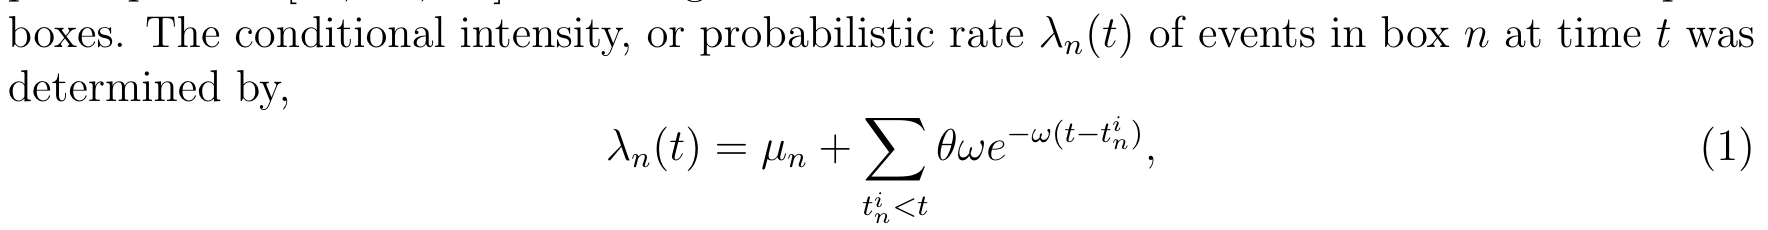

The EM step in Mohler paper is defined as: 

In the E-step, the first probability that is estimated is the probability that event j is a direct offspring of event i. The second one is the probability that the event was generated by the Poisson process μ.

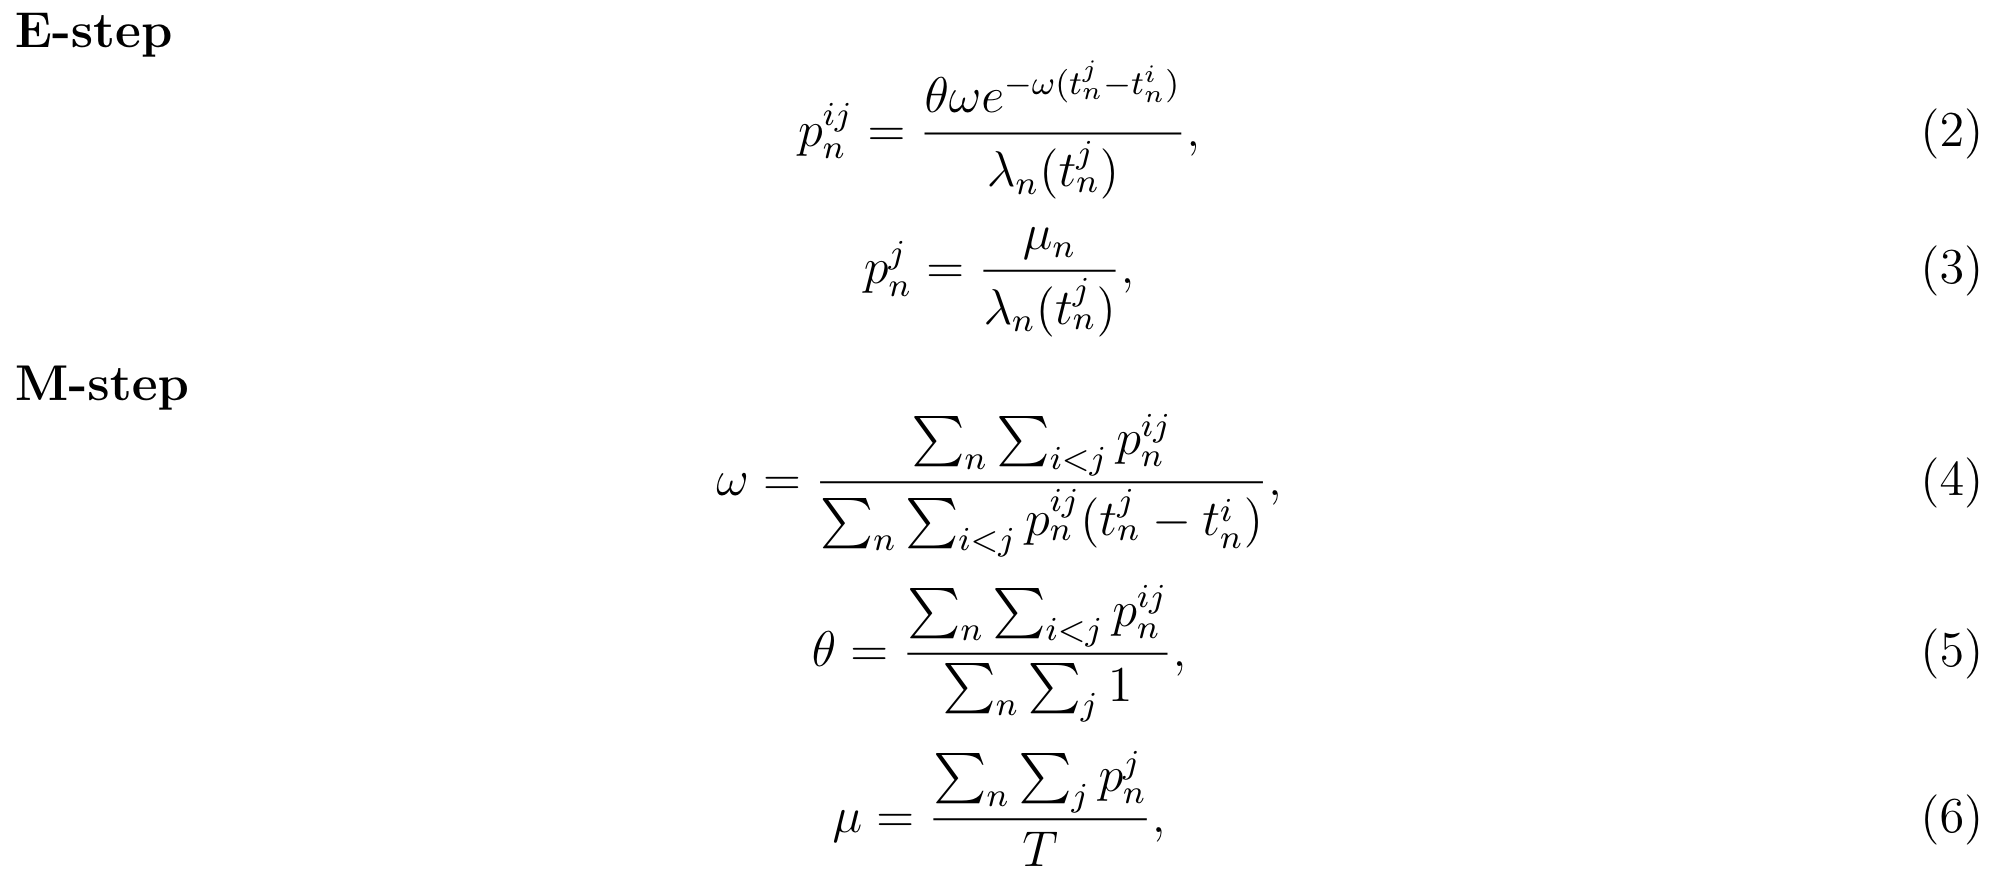

In the M-step, the complete data log-likelihood is then maximized, providing an estimate of the model parameters. For a detailed treatment of the EM algorithm in the context of ETAS see Mohler's previous paper where the EM algorithm is shown to be equivalent to projected gradient ascent optimization on the log-likelihood.

We need to decide how to initialize the three parameters, μ, θ, and ω.

**μ**: This represents the baseline rate of crime and can be initially estimated based on the average rate of crime occurrences per unit time over the observation period. We **initialized** this with a **normalized array of number of crimes in each neighborhood**. This needs to be **lower-bounded** so it doesn't get negative and we don't want zero either. so we set it to **0.1/T**. We chose this because a neighborhood with one crime gets 1/T as μ and a neighborhood with zero crime is not that different from one with one crime, so we don't want one to be less than 0.1 of the other.

**θ**: This parameter represents the strength of the triggering effect, indicating how much an event increases the likelihood of subsequent events. We initialize with 0.2 meaning the expected number of crimes that are triggered by another crime are 0.2, i.e., every 5 crimes can trigger 1 crime. We **upper-bound** it by **0.9**, because going from 1 and above, an even will result in endless chain of events. and we **lower bound** it by **1e-4**.

**ω**: This parameter governs the rate of decay of the triggering effect over time and space. It can be initially estimated based on the observed duration and spatial extent of crime clusters. We start with a reasonable number. I would **initialize** with assuming a crimes effect lasts for two days. so let's say I want the effect of crime to drop to 0.01 (close to zero) after 48 hours. Then we have the equation e ^ (-ω * 48)=0.01
so ω = ln(100)/48 = 0.095... ~ **0.1**

We **upper-bound** ω such that the effect of crime lasts at least 0.5 min=> ln(100)/(0.5/60 hr)= 575 ~ **600**
It can't become negative, because then it would mean the crime will have more effect the more time passes from its occurance which would be illogical. we will **lower bound** it by **0.0005** which will be about 1 year influence.

1e-4 (0.0001) ->5.3 years

1e-3 -> 6.4 month

Note that we are making sure time differences are in hours otherwise our numbers could mean longer or shorter period of time if we don't adjust them to be based on hour.



<!-- To refine the initial guesses, I will run the EM algorithm with different sets of initial parameters and compare the convergence and fit of the resulting models to select the most appropriate values. -->



parameters:
- <b>sDate</b>: datetime.datetime </br> starting date that we wanna decide the allocation for
- <b>df_Crime</b>: Pandas.DataFrame </br> a dataframe containing these columns: year, month,day, neighborhood.
- <b>nei_Names</b>: Pandas.Series </br> a series containing names of the neighborhoods under the observation
- <b>nIter</b>: int </br> number of iterations of the EM algorithm. More iterations helps it fit better but takes more time.

In [15]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
def OptiPredpol(param_df_index, startDate, df_Crime, nei_Names, omega_init=0.5, theta_init=0.2, mu_init=None, nIter=100, tol=1e-5):

    param_tracking_updates=[]
#     one_day_p_tracking=[]
#     crimes_of_day = df_Crimes[df_Crimes['CrimeDateTime'].dt.date == startDate.date()]
#     crimes_of_day_count = crimes_of_day.groupby("Neighborhood").size().reindex(nei_Names, fill_value=0)
#     total_crimes_day = crimes_of_day_count.sum()

    if unexpected_neis := set(df_Crime['Neighborhood']) - set(nei_Names):
        raise ValueError(f"Neighborhoods in df_Crime not present in nei_Names: {unexpected_neis}")

    Crime_hist = df_Crime[(df_Crime['CrimeDateTime'] < startDate) &
                          (df_Crime['CrimeDateTime'] >= startDate - relativedelta(years=1))]
        
    result = pd.DataFrame(index=nei_Names, columns=['Intensity (lambda)', 'DetectedNum'])
    result['DetectedNum'] = 0

    if Crime_hist.empty:
        result['Intensity (lambda)'] = [1 / len(nei_Names)] * len(nei_Names)
        print("crime_hist empty!")
        return result, omega_init, theta_init, mu

    T = (startDate - Crime_hist['CrimeDateTime'].min()).total_seconds() / 3600.0 # all variables should be in same unit of time. we are setting them all to hours
    eps = 0.01 / T # to add to all mu to avoid zero
    
    omega = np.clip(omega_init, 0.0005, 600)
    theta = np.clip(theta_init, 1e-4, 0.9)

    if mu_init is None:
        mu = Crime_hist.groupby(['Neighborhood', 'date']).size().groupby('Neighborhood').mean().reindex(nei_Names, fill_value=0)
        mu = mu + eps
        mu_sum = mu.sum()
        if mu_sum == 0 or np.isnan(mu_sum):
            raise ValueError(f"mu.sum() = {mu_sum}. Check initialization or eps.")
        mu = mu / mu.sum()
    else:
        mu = np.array(mu_init)
        mu = mu + eps
        mu = mu / mu.sum()
    
#     mu = np.clip(mu, 0.01/T, None)  
    
    thet_denum = len(Crime_hist)
    for itr in range(nIter):
        old_omega, old_theta, old_mu = omega, theta, mu.copy()

        omegThet_num = 0
        omeg_denum = 0
        
        for n, nei in enumerate(nei_Names):
            Crime_hist_n = Crime_hist[Crime_hist['Neighborhood'] == nei]
            
            time_diffs = (Crime_hist_n['CrimeDateTime'].values[:, None] -
                          Crime_hist_n['CrimeDateTime'].values[None, :]) / np.timedelta64(1, 'h')
            
            masked_diffs = np.where(time_diffs > 0, time_diffs, np.nan)
            thet_omeg_exp_ijs= theta * omega * np.exp(-omega * masked_diffs)   
            lambda_tjs = np.nansum(thet_omeg_exp_ijs, axis=0) + mu[n]
            
            pjs_vector = mu[n] / lambda_tjs
            pijs_matrix = thet_omeg_exp_ijs / lambda_tjs
            
            omegThet_num += np.nansum(pijs_matrix)
            omeg_denum += np.nansum(pijs_matrix * masked_diffs)
            mu[n]= np.sum(pjs_vector)/T
        
        omega= omegThet_num/ (omeg_denum+ 1e-8)
        theta = omegThet_num/ thet_denum 
        omega = np.clip(omega, 0.0005, 600)
        theta = np.clip(theta, 1e-5, 0.9)
        
        mu = mu + eps  
#         mu = np.clip(mu, 0.01/T, None)      

#         row_day = {
#             **param_df_index,
#             'iter': itr,
#             'omega': omega,
#             'theta': theta,
#         }
#         row_day.update({f'mu_{i}': m for i, m in enumerate(mu)})
#         one_day_p_tracking.append(row_day)         

        if (abs(omega - old_omega) < tol and abs(theta - old_theta) < tol and
                np.all(np.abs(mu - old_mu) < tol)):
            print(f"Converged at iteration {itr}") 
            break

    Crime_hist_copy = Crime_hist.copy()
    Crime_hist_copy['time_diff'] = (startDate - Crime_hist_copy['CrimeDateTime']) / np.timedelta64(1, 'h')
    nei_to_index = {name: i for i, name in enumerate(nei_Names)}
    Crime_hist_copy['nei_idx'] = Crime_hist_copy['Neighborhood'].map(nei_to_index)
    lambdas = np.array(mu, dtype=np.float64)
    decay_values = theta * omega * np.exp(-omega * Crime_hist_copy['time_diff'].values)
    np.add.at(lambdas, Crime_hist_copy['nei_idx'].values, decay_values) # vectorized sum : np.add.at(initial_values, indices, values)
    result['Intensity (lambda)'] = lambdas
    
    row = {
                **param_df_index,
                'iter': itr,
                'omega': omega,
                'theta': theta,
            }
    row.update({f'mu_{i}': m for i, m in enumerate(mu)})
    row.update({f'lambda_{i}': l for i, l in enumerate(result['Intensity (lambda)'].values)})
    param_tracking_updates.append(row)
    
#     one_day_tracking_df = pd.DataFrame(one_day_p_tracking)
#     check_one_day_learning_curve(
#         one_day_tracking_df,
#         crimes_of_day_count=crimes_of_day_count,
#         predicted_lambda_series=pd.Series(lambdas, index=nei_Names, name='lambda'),
#         mu=mu,
#         decay_values=decay_values,           
#         nei_idx=Crime_hist_copy['nei_idx'].values,                     
#         nei_names=nei_Names
#     )

    assert not result['Intensity (lambda)'].isna().any(), "NaN found in lambda calculation"
    return result,omega, theta, mu, param_tracking_updates


In [17]:
#Test
"""s_time = datetime(year=2019, month=1, day=1)
neis=df_neighood.Name
res= prepol(sDate=s_time , df_Crime=df_Crime , nei_Names=neis , omega=0.1 , theta=0.1 , mu=[0.1]*len(neis), nIter=100)
display(res)"""

's_time = datetime(year=2019, month=1, day=1)\nneis=df_neighood.Name\nres= prepol(sDate=s_time , df_Crime=df_Crime , nei_Names=neis , omega=0.1 , theta=0.1 , mu=[0.1]*len(neis), nIter=100)\ndisplay(res)'

In [18]:
def simulateOptiPredPol(md, df_Crime, df_neighood, sDate, eDate, pr, crimeType, policeNum, numberOfRuns, cell_run_time):

    print("Running simulateOptiPredPol!")
    nei_Names = df_neighood.Name

    RRF = create_results_directory('PredPol', md, crimeType, predYear=sDate.year,
                                   numberOfRuns=numberOfRuns, sDate=sDate, eDate=eDate,
                                   PoliceNum=policeNum, cell_run_time=cell_run_time)
    print(RRF)

    if md == 'Monthly':
        sDate = sDate.replace(day=1)

    avgNeiRes, dates_And_Next = createAverageNeighborResultDF(md, df_Crime, df_neighood, sDate, eDate, pr)
    
    
    print("Going through " + str(numberOfRuns) + " rounds of the simulation:")

    for run in tqdm(range(numberOfRuns), leave=True):
        crime_hist = df_Crime[df_Crime['CrimeDateTime'] < sDate]
        

        for pReport in tqdm(pr, total=len(pr), leave=False):
            warnings.filterwarnings("ignore")
            
            parameter_tracking=[]
            
            omega_init=0.3
            theta_init=0.2
            mu_init=None
            
            previous_omega, previous_theta = omega_init, theta_init
            previous_mu = None if mu_init is None else mu_init.copy()

            detectedCrimes = pd.DataFrame(columns=df_Crime.columns)
            reportedCrimes = pd.read_csv(f"Data Frames/Others/Reported/2019/{crimeType}/pReport-{pReport}.csv")

            map_data = []

            for start, nextDate in dates_And_Next:
                crimes = pd.concat([crime_hist, detectedCrimes, reportedCrimes]).drop_duplicates()
                crimes['CrimeDateTime'] = pd.to_datetime(crimes['CrimeDateTime'])

                res, omega, theta, mu, param_tracking_updates = OptiPredpol(
                    param_df_index= {'run': run,'pReport': pReport,'date': start},
                    startDate = start, df_Crime = crimes, nei_Names = nei_Names, 
                    omega_init = previous_omega, theta_init = previous_theta, mu_init= previous_mu,
                    nIter=100, tol=1e-3)
                
                previous_omega, previous_theta, previous_mu = omega, theta, mu.copy()
                parameter_tracking.extend(param_tracking_updates)
                
                    
                res['Intensity (lambda)'] /= np.sum(res['Intensity (lambda)'])
                         

                res['PoliceNum'] = np.random.multinomial(policeNum, res['Intensity (lambda)'])

                avgNeiRes.loc[((avgNeiRes.pReport == pReport) &
                               (avgNeiRes.Date.dt.date == start.date())), 'PoliceNum'] += (
                               res['PoliceNum'] / numberOfRuns).to_numpy()

                if run == 0 and (start == sDate or nextDate == eDate):
                    map_data.append({'date': start,
                                     'p_locations': res,
                                     'c_locations': df_Crime[(df_Crime['CrimeDateTime'] >= start) &
                                                            (df_Crime['CrimeDateTime'] < nextDate)]})

                res['area'] = df_neighood['SHAPE__Area'].to_numpy()
                res['rescaledArea'] = rescale2(res['area'], 1, 10).to_numpy()
                res['policeOverArea'] = res['PoliceNum'] / res['rescaledArea']
                res['policeOverArea'] = rescale2(data=res['policeOverArea'], minVal=0, maxVal=10).to_numpy()

                crimesNow = df_Crime[(df_Crime['CrimeDateTime'] >= start) & (df_Crime['CrimeDateTime'] < nextDate)]
                crimesNow_PoD = 1 - pow(0.5, crimesNow['Neighborhood'].map(res['policeOverArea']))

                rands = np.round(np.random.random(len(crimesNow)), 2)
                boolsDetected = rands < crimesNow_PoD
                detectedCrimes = pd.concat([detectedCrimes, crimesNow[boolsDetected]], ignore_index=True)

                crimesNow['Detected'] = boolsDetected
                detectedNum_series = crimesNow.groupby('Neighborhood')['Detected'].sum()
                res['DetectedNum'].update(detectedNum_series)

                avgNeiRes.loc[((avgNeiRes.pReport == pReport) &
                               (avgNeiRes.Date.dt.date == start.date())), 'DetectedNum'] += (
                               res['DetectedNum'] / numberOfRuns).to_numpy()

                res.to_csv(f"{RRF}allRes/pReport_{pReport}-Date_{start.date()}-PredResult.csv", index=True)

            if run == 0:
                save_maps('PredPol', map_data,
                          dest=f'{RRF}maps/pReport_{pReport}.html',
                          df_neighood=df_neighood)
                parameter_tracking_df= pd.DataFrame(parameter_tracking)
                parameter_tracking_df.to_csv(f"{RRF}parameter_tracking.csv", index=False)
                check_predPol_learning(parameter_tracking_df, df_Crime,nei_Names, run_filter=run, pReport_filter= pReport)

    avgNeiRes.to_csv(f'{RRF}parallelOptiPred_AverageNeighborResult.csv', index=False)
    

    return avgNeiRes, f'{RRF}parallelOptiPred_AverageNeighborResult.csv'


### Faster PredPol with a Parallelization over Report Probabilities and runs

In [19]:
def processReportProbs_pred(pReport, dates_And_Next, run, nei_Names , aNR,df_Crime, crime_hist,numberOfRuns,policeNum, RRF,crimeType):
    """
    parameters:
     pReport, dates_And_Next, run, nei_Names , avgNeiRes, crime_hist
    
    """
    warnings.filterwarnings("ignore")
    
    parameter_tracking=[]
    omega_init=0.3
    theta_init=0.2
    mu_init=None

    previous_omega, previous_theta = omega_init, theta_init
    previous_mu = None if mu_init is None else mu_init.copy()
    
    detectedCrimes = pd.DataFrame(columns = df_Crime.columns)
    reportedCrimes = pd.read_csv(f"Data Frames/Others/Reported/2019/{crimeType}/pReport-{pReport}.csv")

    map_data = []
    
    avgNeiRes_local = aNR.copy()
    
    for start, nextDate in dates_And_Next: # in tqdm(dates_And_Next, total=len(dates_And_Next), leave=False):
    

        crimes = pd.concat([crime_hist, detectedCrimes, reportedCrimes]).drop_duplicates()
        crimes['CrimeDateTime'] = pd.to_datetime(crimes['CrimeDateTime'])

        res, omega, theta, mu, param_tracking_updates = OptiPredpol(
                    param_df_index= {'run': run,'pReport': pReport,'date': start},
                    startDate = start, df_Crime = crimes, nei_Names = nei_Names, 
                    omega_init = previous_omega, theta_init = previous_theta, mu_init= previous_mu,
                    nIter=100, tol=1e-3)
                
        previous_omega, previous_theta, previous_mu = omega, theta, mu.copy()
        parameter_tracking.extend(param_tracking_updates)

        res['Intensity (lambda)'] /= np.sum(res['Intensity (lambda)'])
   
        #avgNeiRes_local.loc[((avgNeiRes_local.pReport==pReport) &(avgNeiRes_local.Date.dt.date==start.date())), 'Intensity (lambda)'] = (res['Intensity (lambda)']/numberOfRuns).to_numpy()


        res['PoliceNum'] = np.random.multinomial(policeNum,res['Intensity (lambda)'])
   
        avgNeiRes_local.loc[((avgNeiRes_local.pReport==pReport) &(avgNeiRes_local.Date.dt.date==start.date())), 'PoliceNum'] = (res['PoliceNum']/numberOfRuns).to_numpy()

        if run == 0 and (start==sDate or nextDate==eDate): 
            map_data.append({'date':start,
                             'p_locations': res,
                             'c_locations': df_Crime[(df_Crime['CrimeDateTime'] >= start) & (df_Crime['CrimeDateTime'] < nextDate) ] 
                            })


        res['area'] = df_neighood['SHAPE__Area'].to_numpy()

        #let's rescale area to numbers between 1 and 10
        res['rescaledArea'] = rescale2(res['area'], 1,10).to_numpy()

        res['policeOverArea'] = (res['PoliceNum']/res['rescaledArea']).to_numpy()
        #I want to rescale PoliceOverArea to numbers between 0 to 10, that way the probability of 
        #detection (1- pow(0.5 , PoliceOverArea)) will range between 0.5 and 0.999.
        res['policeOverArea'] = rescale2(data = res['policeOverArea'], minVal = 0, maxVal = 10).to_numpy()


        crimesNow = df_Crime[(df_Crime['CrimeDateTime'] >= start) & (df_Crime['CrimeDateTime'] < nextDate)] 
        #res['CrimesNum']= [len(crimesNow[crimesNow['Neighborhood']==nei]) for nei in nei_Names]

        #step 4.4.i.1: Flip coin with probability detect_prob. If heads, detected_crimes_m = detected_crimes_m + c  // (latitude, longitude) 
        #Note: this is the same as noisy-or model: p(detected) = 1 - (1 - detect_prob)^(# policeOverArea) 

        #Noisy-OR:
        #today's crimes' Probability of Detection
        crimesNow_PoD =  1-pow(0.5, crimesNow['Neighborhood'].map(res['policeOverArea']))

        #flipping the coin:
        #temp = rand(0,1)
        #if temp < prob, success = true
        #else success = false
        rands= np.round(np.random.random(len(crimesNow)), 2)
        boolsDetected = rands < crimesNow_PoD #boolsDetected type: pd.series

        detectedCrimes = detectedCrimes.append(crimesNow[boolsDetected], ignore_index=True)

        crimesNow['Detected'] = boolsDetected
        detectedNum_series = crimesNow.groupby('Neighborhood')['Detected'].sum()
        res['DetectedNum'].update(detectedNum_series)

        avgNeiRes_local.loc[((avgNeiRes_local.pReport == pReport) & (avgNeiRes_local.Date.dt.date == start.date())), 'DetectedNum'] = (res['DetectedNum']/numberOfRuns).to_numpy()
        res.to_csv(f"{RRF}allRes/pReport_{pReport}-Date_{start.date()}-PredResult.csv", index=False)
    #for date closed
    if run == 0:
        save_maps('PredPol', map_data, dest = f'{RRF}maps/pReport_{pReport}.html', df_neighood = df_neighood)
        parameter_tracking_df= pd.DataFrame(parameter_tracking)
        parameter_tracking_df.to_csv(f"{RRF}parameter_tracking.csv", index=False)
        check_predPol_learning(parameter_tracking_df, df_Crime,nei_Names)
        
    return avgNeiRes_local


### Optimized Use of Cores with Flat Parallel

In [20]:
def flat_parallel_simulations_predpol(md, df_Crime, df_neighood, sDate, eDate, pr, 
                                      crimeType, policeNum, numberOfRuns, cell_run_time):

    print("Running simulateOptiPredPol!")
    nei_Names = df_neighood.Name

    RRF = create_results_directory('PredPol', md, crimeType, predYear=sDate.year,
                                   numberOfRuns=numberOfRuns, sDate=sDate, eDate=eDate,
                                   PoliceNum=policeNum, cell_run_time=cell_run_time)
    print(RRF)

    if md == 'Monthly':
        sDate = sDate.replace(day=1)

    avgNeiRes, dates_And_Next = createAverageNeighborResultDF(md, df_Crime, df_neighood, sDate, eDate, pr)
    avgNeiRes_copy=avgNeiRes.copy()
    
    print("Going through " + str(numberOfRuns) + " rounds of the simulation:")

    crime_hist = df_Crime[df_Crime['CrimeDateTime'] < sDate]

    results = Parallel(n_jobs=9)(
        delayed(processReportProbs_pred)(
            pReport=pReport,
            dates_And_Next=dates_And_Next, 
            run=run, nei_Names=nei_Names, 
            aNR=avgNeiRes_copy, 
            df_Crime=df_Crime, 
            crime_hist=crime_hist, 
            numberOfRuns=numberOfRuns, 
            policeNum=policeNum,
            RRF=RRF, crimeType=crimeType
        )
        for run in range(numberOfRuns)
        for pReport in tqdm(pr, desc=f"Run {run}", leave=False)
    )

    avgNeiRes[['PoliceNum', 'DetectedNum']] = 0
    for partial in results:
        avgNeiRes[['PoliceNum', 'DetectedNum']] += partial[['PoliceNum', 'DetectedNum']]

    output_path = f'{RRF}flat_OptiPred_AverageNeighborResult.csv'
    avgNeiRes.to_csv(output_path, index=False)
    return avgNeiRes, output_path


---

## Implementing KDE - Long-term ( Using All Crime-History Provided)

KDE is used here as a representative of hotspot policing, while prePol is a representative of Predictive Policing algorithms which learn a model to use for prediction.

In [21]:
def KDE_Long_simulate (md, df_Crime, df_neighood, sDate, eDate, pr, crimeType, policeNum, numberOfRuns ):
   
    """
    md: string
        "Daily" for daily prediction, "Monthly" for monthly prediction
    pr: array
        an array containing all the probability of reports we want to try. 
        In our preprocessing we have only build up reportedCrimes csv files with these probability of 
        reports:[0.0, 0.1, 0.2, ..., 1.0]. If you want other report probabilities you have to first build 
        the csv file in the preprocessing ipynb file.
        
    """
        
    RRF = create_results_directory('KDE',md, crimeType, predYear=sDate.year, numberOfRuns=numberOfRuns, sDate=sDate, eDate=eDate, PoliceNum=policeNum)
    print(RRF)
    if md == 'Monthly':
        sDate = sDate.replace(day = 1)
        
    avgNeiRes, dates_And_Next = createAverageNeighborResultDF(md, df_Crime, df_neighood, sDate, eDate, pr)
    #avgNeiRes['Date']= pd.to_datetime(avgNeiRes['Date']).dt.date
    
    avgNeiRes_copy = avgNeiRes.copy()
    
    crime_hist = df_Crime[df_Crime['CrimeDateTime'] < sDate]
    
    print("Going through "+str(numberOfRuns)+" rounds of the semulation:")
    with tqdm(total=numberOfRuns) as pbar:
        for run in range(numberOfRuns):

            with tqdm(total=len(pr), leave=False) as pbar2:
                for pReport in pr:
                    
                    start = sDate

                    detectedCrimes = pd.DataFrame(columns = df_Crime.columns)
                    reportedCrimes = pd.read_csv(f"Data Frames/Others/Reported/2019/{crimeType}/pReport-{pReport}.csv")
                   
                    map_data=[]
                    for start, nextDate in dates_And_Next:
                            
#                         previousDate = start - relativedelta(months=1)
                            
                        
                        crimes = pd.concat([crime_hist, detectedCrimes, reportedCrimes]).drop_duplicates()
                        crimes['CrimeDateTime']= pd.to_datetime(crimes['CrimeDateTime'])
                        
                        
#                         crimes_to_use = crimes[(crimes['CrimeDateTime'] >= previousDate) & (crimes['CrimeDateTime'] < start)] 
                        
#                         month_ago = 2
#                         while( len(crimes_to_use)==0):
            
#                             dayBeforePrevious = start - relativedelta(months = month_ago)
#                             crimes_to_use = crimes[(crimes['CrimeDateTime'] >= dayBeforePrevious) & (crimes['CrimeDateTime'] < start)] 
                        
#                             print("in simulate function!")
#                             #print(f"Empty previous day crime! crime-length of the day before last:{len(crimes)}.")
#                             print("previousDate: ",previousDate)
#                             print("start: ",start )
#                             print("pReport: ", pReport)
#                             month_ago += 1
#                             #sys.exit()
                            
#                         crimes = crimes_to_use
                        
                        police_KDE=  KernelDensity(kernel='gaussian', bandwidth=0.00005).fit(crimes[[ 'Latitude' ,'Longitude']].values)
                        police_loc = police_KDE.sample(n_samples = policeNum, random_state = 3)
                        police_locations = pd.DataFrame(police_loc, columns = ['Latitude','Longitude'])
                        if run==0 and (start==sDate or start==eDate): 
                            map_data.append({'date':start,
                                             'p_locations':police_locations,
                                             'c_locations':df_Crime[(df_Crime['CrimeDateTime'] >= start) & (df_Crime['CrimeDateTime'] < nextDate)] })
                        
                        res = PoliceInNeighood(police_locations)
                        
                        avgNeiRes.loc[((avgNeiRes.pReport==pReport) &(avgNeiRes.Date.dt.date==start.date())), 'PoliceNum'] += (res['PoliceNum']/numberOfRuns).to_numpy()


                        res['area']= df_neighood['SHAPE__Area'].to_numpy()

                        #let's rescale area to numbers between 1 and 10
                        res['rescaledArea'] = rescale2(res['area'], 1,10).to_numpy()

                        res['policeOverArea'] = (res['PoliceNum']/res['rescaledArea']).to_numpy()
                        #I want to rescale PoliceOverArea to numbers between 0 to 10, that way the probability of 
                        #detection (1- pow(0.5 , PoliceOverArea)) will range between 0.5 and 0.999.
                        res['policeOverArea']= rescale2(data=res['policeOverArea'], minVal=0, maxVal=10).to_numpy()

                        crimesNow = df_Crime[(df_Crime['CrimeDateTime'] >= start) & (df_Crime['CrimeDateTime'] < nextDate)] 
                        #res['CrimesNum']= [len(crimesNow[crimesNow['Neighborhood']==nei]) for nei in nei_Names]
                        
                        #step 4.4.i.1: Flip coin with probability detect_prob. If heads, detected_crimes_m = detected_crimes_m + c  // (latitude, longitude) 
                        #Note: this is the same as noisy-or model: p(detected) = 1 - (1 - detect_prob)^(# policeOverArea) 

                        #Noisy-OR:
                        #today's crimes' Probability of Detection
                        crimesNow_PoD =  1-pow(0.5, crimesNow['Neighborhood'].map(res['policeOverArea']))

                        #flipping the coin:
                        #temp = rand(0,1)
                        #if temp < prob, success = true
                        #else success = false
                        rands= np.round(np.random.random(len(crimesNow)), 2)
                        boolsDetected = rands< crimesNow_PoD #boolsDetected type: pd.series

                        detectedCrimes = detectedCrimes.append(crimesNow[boolsDetected], ignore_index=True)

                        crimesNow['Detected'] = boolsDetected
                        detectedNum_series = crimesNow.groupby('Neighborhood')['Detected'].sum()
                        res['DetectedNum'].update(detectedNum_series)
                        
                        avgNeiRes.loc[((avgNeiRes.pReport==pReport) &(avgNeiRes.Date.dt.date==start.date())), 'DetectedNum'] += (res['DetectedNum']/numberOfRuns).to_numpy()
                        res.to_csv(f'{RRF}allRes/pReport_{pReport}-Date_{start.date()}-Result.csv', index=True)
                        start = nextDate
                    if run==0:
                        save_maps('KDE', map_data, dest=f'{RRF}/maps/pReport_{pReport}.html', df_neighood= df_neighood)
                    pbar2.update()
                    
                #for pReport closing

            pbar.update()
        #for run closing
        
    resLoc = RRF+'AverageNeighborResult.csv'
    avgNeiRes.to_csv(resLoc, index=False)
    
    return avgNeiRes, resLoc

        
            

### Faster KDE Simulation with Parallelization over Report Probabilities

In [22]:
def processReportProbs_kde_Long(pReport, aNR, sDate, df_Crime, crime_hist, crimeType, dates_And_Next, policeNum, run, RRF,numberOfRuns):
    
    warnings.filterwarnings("ignore")
    
    avgNeiRes_local = aNR.copy()
    

    start = sDate

    detectedCrimes = pd.DataFrame(columns = df_Crime.columns)
    reportedCrimes = pd.read_csv(f"Data Frames/Others/Reported/2019/{crimeType}/pReport-{pReport}.csv")
    
    map_data=[]
    for start, nextDate in dates_And_Next:

#         previousDate = start - relativedelta(months=1)

        crimes = pd.concat([crime_hist, detectedCrimes, reportedCrimes]).drop_duplicates()
        crimes['CrimeDateTime']= pd.to_datetime(crimes['CrimeDateTime'])


#         crimes_to_use = crimes[(crimes['CrimeDateTime'] >= previousDate) & (crimes['CrimeDateTime'] < start)] 

#         month_ago = 2
#         while( len(crimes_to_use)==0):

#             dayBeforePrevious = start - relativedelta(months = month_ago)
#             crimes_to_use = crimes[(crimes['CrimeDateTime'] >= dayBeforePrevious) & (crimes['CrimeDateTime'] < start)] 

#             print("in process_pReport_iterations function")
#             print(f"Empty previous day crime! crime-length of {month_ago} day/s before last:{len(crimes_to_use)}.")
#             print("previousDate: ",previousDate)
#             print("start: ",start )
#             print("pReport: ", pReport)
#             month_ago += 1
#             #sys.exit()

#         crimes = crimes_to_use

        police_KDE=  KernelDensity(kernel='gaussian', bandwidth=0.00005).fit(crimes[[ 'Latitude' ,'Longitude']].values)
        police_loc = police_KDE.sample(n_samples = policeNum, random_state = 3)
        police_locations = pd.DataFrame(police_loc, columns = ['Latitude','Longitude'])
        if run==0 and (start==sDate or nextDate==eDate): 
            map_data.append({'date':start,
                             'p_locations':police_locations,
                             'c_locations':df_Crime[(df_Crime['CrimeDateTime'] >= start) & (df_Crime['CrimeDateTime'] < nextDate)] })

        res = PoliceInNeighood(police_locations)

        avgNeiRes_local.loc[((avgNeiRes_local.pReport==pReport) &(avgNeiRes_local.Date.dt.date==start.date())), 'PoliceNum'] = (res['PoliceNum']/numberOfRuns).to_numpy()


        res['area']= df_neighood['SHAPE__Area'].to_numpy()

        #let's rescale area to numbers between 1 and 10
        res['rescaledArea'] = rescale2(res['area'], 1,10).to_numpy()

        res['policeOverArea'] = (res['PoliceNum']/res['rescaledArea']).to_numpy()
        #I want to rescale PoliceOverArea to numbers between 0 to 10, that way the probability of 
        #detection (1- pow(0.5 , PoliceOverArea)) will range between 0.5 and 0.999.
        res['policeOverArea']= rescale2(data=res['policeOverArea'], minVal=0, maxVal=10).to_numpy()

        crimesNow = df_Crime[(df_Crime['CrimeDateTime'] >= start) & (df_Crime['CrimeDateTime'] < nextDate)] 

        #step 4.4.i.1: Flip coin with probability detect_prob. If heads, detected_crimes_m = detected_crimes_m + c  // (latitude, longitude) 
        #Note: this is the same as noisy-or model: p(detected) = 1 - (1 - detect_prob)^(# policeOverArea) 

        #Noisy-OR:
        #today's crimes' Probability of Detection
        crimesNow_PoD =  1-pow(0.5, crimesNow['Neighborhood'].map(res['policeOverArea']))

        #flipping the coin:
        #temp = rand(0,1)
        #if temp < prob, success = true
        #else success = false
        rands= np.round(np.random.random(len(crimesNow)), 2)
        boolsDetected = rands< crimesNow_PoD #boolsDetected type: pd.series

        detectedCrimes = detectedCrimes.append(crimesNow[boolsDetected], ignore_index=True)

        crimesNow['Detected'] = boolsDetected
        detectedNum_series = crimesNow.groupby('Neighborhood')['Detected'].sum()
        res['DetectedNum'].update(detectedNum_series)

        avgNeiRes_local.loc[((avgNeiRes_local.pReport==pReport) &(avgNeiRes_local.Date.dt.date==start.date())), 'DetectedNum'] = (res['DetectedNum']/numberOfRuns).to_numpy()
        res.to_csv(f'{RRF}allRes/pReport_{pReport}-Date_{start.date()}-Result.csv', index=False)
        start = nextDate
    if run==0:
        save_maps('KDE', map_data, dest=f'{RRF}/maps/pReport_{pReport}.html', df_neighood= df_neighood)

       
    return avgNeiRes_local


In [23]:
def flat_parallel_simulations_KDE_Long(md, df_Crime, df_neighood, sDate, eDate, pr, crimeType, policeNum, numberOfRuns,cell_run_time):
    
    RRF = create_results_directory('KDE',md, crimeType, predYear=sDate.year, numberOfRuns=numberOfRuns, sDate=sDate, eDate=eDate, PoliceNum=policeNum,cell_run_time=cell_run_time)
    print(RRF)
    if md == 'Monthly':
        sDate = sDate.replace(day = 1)
        
    avgNeiRes, dates_And_Next = createAverageNeighborResultDF(md, df_Crime, df_neighood, sDate, eDate, pr)
    #avgNeiRes['Date']= pd.to_datetime(avgNeiRes['Date']).dt.date
    
    avgNeiRes_copy = avgNeiRes.copy()
    crime_hist = df_Crime[df_Crime['CrimeDateTime'] < sDate]
    
    print("Going through "+str(numberOfRuns)+" rounds of the simulation:")

    results = Parallel(n_jobs=9)(
        delayed(processReportProbs_kde_Long)(
        
            pReport=pReport,
            dates_And_Next=dates_And_Next, 
            run=run, 
            aNR=avgNeiRes_copy, 
            df_Crime=df_Crime, 
            crime_hist=crime_hist,
            crimeType=crimeType,
            numberOfRuns=numberOfRuns, 
            policeNum=policeNum,
            RRF=RRF, sDate=sDate,
        )
        for run in range(numberOfRuns)
        for pReport in tqdm(pr, desc=f"Run {run}", leave=True)
    )

    avgNeiRes[['PoliceNum', 'DetectedNum']] = 0
    for partial in results:
        avgNeiRes[['PoliceNum', 'DetectedNum']] += partial[['PoliceNum', 'DetectedNum']]

    output_path = f'{RRF}flat_KDE_AverageNeighborResult.csv'
    avgNeiRes.to_csv(output_path, index=False)
    
    return avgNeiRes, output_path


---

## Implementing KDE- Short-term ( Using The Last Month Crime-History Prior to Each Prediction Date) 

In [24]:
def KDE_Short_simulate (md, df_Crime, df_neighood, sDate, eDate, pr, crimeType, policeNum, numberOfRuns ):
   
    """
    md: char
        "D" for daily prediction, "M" for monthly prediction
    pr: array
        an array containing all the probability of reports we want to try. 
        In our preprocessing we have only build up reportedCrimes csv files with these probability of 
        reports:[0.0, 0.1, 0.2, ..., 1.0]. If you want other report probabilities you have to first build 
        the csv file in the preprocessing ipynb file.
        
    """
        
    RRF = create_results_directory('KDE',md, crimeType, predYear=sDate.year, numberOfRuns=numberOfRuns, sDate=sDate, eDate=eDate, PoliceNum=policeNum)
    print(RRF)
    if md == 'M':
        sDate = sDate.replace(day = 1)
        
    avgNeiRes, dates_And_Next = createAverageNeighborResultDF(md, df_Crime, df_neighood, sDate, eDate, pr)
    #avgNeiRes['Date']= pd.to_datetime(avgNeiRes['Date']).dt.date
    
    avgNeiRes_copy = avgNeiRes.copy()
    
    print("Going through "+str(numberOfRuns)+" rounds of the semulation:")
    with tqdm(total=numberOfRuns) as pbar:
        for run in range(numberOfRuns):

            with tqdm(total=len(pr), leave=False) as pbar2:
                for pReport in pr:
                    
                    start = sDate

                    detectedCrimes = pd.DataFrame(columns = df_Crime.columns)
                
                    
                    past = sDate - relativedelta(months=1)
                    detectedCrimes = df_Crime[(df_Crime['CrimeDateTime'] >= past) & (df_Crime['CrimeDateTime'] < sDate)] 
                        
                    reportedCrimes = pd.read_csv("Data Frames/Others/Reported/AllYears/"+ crimeType + "/pReport-"+str(pReport)+".csv")
                   
                    map_data=[]
                    for start, nextDate in dates_And_Next:
                            
                        previousDate = start - relativedelta(months=1)
                            
                        crimes = pd.concat([detectedCrimes, reportedCrimes]).drop_duplicates()
                        crimes['CrimeDateTime']= pd.to_datetime(crimes['CrimeDateTime'])
                        
                        
                        crimes_to_use = crimes[(crimes['CrimeDateTime'] >= previousDate) & (crimes['CrimeDateTime'] < start)] 
                        
                        month_ago = 2
                        while( len(crimes_to_use)==0):
            
                            dayBeforePrevious = start - relativedelta(months = month_ago)
                            crimes_to_use = crimes[(crimes['CrimeDateTime'] >= dayBeforePrevious) & (crimes['CrimeDateTime'] < start)] 
                        
                            print("in simulate function!")
                            #print(f"Empty previous day crime! crime-length of the day before last:{len(crimes)}.")
                            print("previousDate: ",previousDate)
                            print("start: ",start )
                            print("pReport: ", pReport)
                            month_ago += 1
                            #sys.exit()
                            
                        crimes = crimes_to_use
                        
                        police_KDE=  KernelDensity(kernel='gaussian', bandwidth=0.00005).fit(crimes[[ 'Latitude' ,'Longitude']].values)
                        police_loc = police_KDE.sample(n_samples = policeNum, random_state = 3)
                        police_locations = pd.DataFrame(police_loc, columns = ['Latitude','Longitude'])
                        if run==0 and (start==sDate or start==eDate): 
                            map_data.append({'date':start,
                                             'p_locations':police_locations,
                                             'c_locations':df_Crime[(df_Crime['CrimeDateTime'] >= start) & (df_Crime['CrimeDateTime'] < nextDate)] })
                        
                        res = PoliceInNeighood(police_locations)
                        
                        avgNeiRes.loc[((avgNeiRes.pReport==pReport) &(avgNeiRes.Date.dt.date==start.date())), 'PoliceNum'] += (res['PoliceNum']/numberOfRuns).to_numpy()


                        res['area']= df_neighood['SHAPE__Area'].to_numpy()

                        #let's rescale area to numbers between 1 and 10
                        res['rescaledArea'] = rescale2(res['area'], 1,10).to_numpy()

                        res['policeOverArea'] = (res['PoliceNum']/res['rescaledArea']).to_numpy()
                        #I want to rescale PoliceOverArea to numbers between 0 to 10, that way the probability of 
                        #detection (1- pow(0.5 , PoliceOverArea)) will range between 0.5 and 0.999.
                        res['policeOverArea']= rescale2(data=res['policeOverArea'], minVal=0, maxVal=10).to_numpy()

                        crimesNow = df_Crime[(df_Crime['CrimeDateTime'] >= start) & (df_Crime['CrimeDateTime'] < nextDate)] 
                        #res['CrimesNum']= [len(crimesNow[crimesNow['Neighborhood']==nei]) for nei in nei_Names]
                        
                        #step 4.4.i.1: Flip coin with probability detect_prob. If heads, detected_crimes_m = detected_crimes_m + c  // (latitude, longitude) 
                        #Note: this is the same as noisy-or model: p(detected) = 1 - (1 - detect_prob)^(# policeOverArea) 

                        #Noisy-OR:
                        #today's crimes' Probability of Detection
                        crimesNow_PoD =  1-pow(0.5, crimesNow['Neighborhood'].map(res['policeOverArea']))

                        #flipping the coin:
                        #temp = rand(0,1)
                        #if temp < prob, success = true
                        #else success = false
                        rands= np.round(np.random.random(len(crimesNow)), 2)
                        boolsDetected = rands< crimesNow_PoD #boolsDetected type: pd.series

                        detectedCrimes = detectedCrimes.append(crimesNow[boolsDetected], ignore_index=True)

                        crimesNow['Detected'] = boolsDetected
                        detectedNum_series = crimesNow.groupby('Neighborhood')['Detected'].sum()
                        res['DetectedNum'].update(detectedNum_series)
                        
                        avgNeiRes.loc[((avgNeiRes.pReport==pReport) &(avgNeiRes.Date.dt.date==start.date())), 'DetectedNum'] += (res['DetectedNum']/numberOfRuns).to_numpy()
                        res.to_csv(f'{RRF}allRes/pReport_{pReport}-Date_{start.date()}-Result.csv', index=True)
                        start = nextDate
                    if run==0:
                        save_maps('KDE', map_data, dest=f'{RRF}/maps/pReport_{pReport}.html', df_neighood= df_neighood)
                    pbar2.update()
                    
                #for pReport closing

            pbar.update()
        #for run closing
        
    resLoc = RRF+'AverageNeighborResult.csv'
    avgNeiRes.to_csv(resLoc, index=True)
    
    return avgNeiRes, resLoc

        
            

In [25]:
def processReportProbs_kde_Short(pReport, aNR, sDate, df_Crime, crimeType, dates_And_Next, policeNum, run, RRF, numberOfRuns):
    
    warnings.filterwarnings("ignore")
    
    
    avgNeiRes_local = aNR.copy()
    

    start = sDate

    detectedCrimes = pd.DataFrame(columns = df_Crime.columns)


    past = sDate - relativedelta(months=1)
    detectedCrimes = df_Crime[(df_Crime['CrimeDateTime'] >= past) & (df_Crime['CrimeDateTime'] < sDate)] 

    reportedCrimes = pd.read_csv("Data Frames/Others/Reported/AllYears/"+ crimeType + "/pReport-"+str(pReport)+".csv")

    map_data=[]
    for start, nextDate in dates_And_Next:

        previousDate = start - relativedelta(months=1)

        crimes = pd.concat([detectedCrimes, reportedCrimes]).drop_duplicates()
        crimes['CrimeDateTime']= pd.to_datetime(crimes['CrimeDateTime'])


        crimes_to_use = crimes[(crimes['CrimeDateTime'] >= previousDate) & (crimes['CrimeDateTime'] < start)] 

        month_ago = 2
        while( len(crimes_to_use)==0):

            dayBeforePrevious = start - relativedelta(months = month_ago)
            crimes_to_use = crimes[(crimes['CrimeDateTime'] >= dayBeforePrevious) & (crimes['CrimeDateTime'] < start)] 

            print("in process_pReport_iterations function")
            print(f"Empty previous day crime! crime-length of {month_ago} day/s before last:{len(crimes_to_use)}.")
            print("previousDate: ",previousDate)
            print("start: ",start )
            print("pReport: ", pReport)
            month_ago += 1
            #sys.exit()

        crimes = crimes_to_use

        police_KDE=  KernelDensity(kernel='gaussian', bandwidth=0.00005).fit(crimes[[ 'Latitude' ,'Longitude']].values)
        police_loc = police_KDE.sample(n_samples = policeNum, random_state = 3)
        police_locations = pd.DataFrame(police_loc, columns = ['Latitude','Longitude'])
        if run==0 and (start==sDate or nextDate==eDate): 
            map_data.append({'date':start,
                             'p_locations':police_locations,
                             'c_locations':df_Crime[(df_Crime['CrimeDateTime'] >= start) & (df_Crime['CrimeDateTime'] < nextDate)] })

        res = PoliceInNeighood(police_locations)

        avgNeiRes_local.loc[((avgNeiRes_local.pReport==pReport) &(avgNeiRes_local.Date.dt.date==start.date())), 'PoliceNum'] = (res['PoliceNum']/numberOfRuns).to_numpy()


        res['area']= df_neighood['SHAPE__Area'].to_numpy()

        #let's rescale area to numbers between 1 and 10
        res['rescaledArea'] = rescale2(res['area'], 1,10).to_numpy()

        res['policeOverArea'] = (res['PoliceNum']/res['rescaledArea']).to_numpy()
        #I want to rescale PoliceOverArea to numbers between 0 to 10, that way the probability of 
        #detection (1- pow(0.5 , PoliceOverArea)) will range between 0.5 and 0.999.
        res['policeOverArea']= rescale2(data=res['policeOverArea'], minVal=0, maxVal=10).to_numpy()

        crimesNow = df_Crime[(df_Crime['CrimeDateTime'] >= start) & (df_Crime['CrimeDateTime'] < nextDate)] 

        #step 4.4.i.1: Flip coin with probability detect_prob. If heads, detected_crimes_m = detected_crimes_m + c  // (latitude, longitude) 
        #Note: this is the same as noisy-or model: p(detected) = 1 - (1 - detect_prob)^(# policeOverArea) 

        #Noisy-OR:
        #today's crimes' Probability of Detection
        crimesNow_PoD =  1-pow(0.5, crimesNow['Neighborhood'].map(res['policeOverArea']))

        #flipping the coin:
        #temp = rand(0,1)
        #if temp < prob, success = true
        #else success = false
        rands= np.round(np.random.random(len(crimesNow)), 2)
        boolsDetected = rands< crimesNow_PoD #boolsDetected type: pd.series

        detectedCrimes = detectedCrimes.append(crimesNow[boolsDetected], ignore_index=True)

        crimesNow['Detected'] = boolsDetected
        detectedNum_series = crimesNow.groupby('Neighborhood')['Detected'].sum()
        res['DetectedNum'].update(detectedNum_series)

        avgNeiRes_local.loc[((avgNeiRes_local.pReport==pReport) &(avgNeiRes_local.Date.dt.date==start.date())), 'DetectedNum'] = (res['DetectedNum']/numberOfRuns).to_numpy()
        res.to_csv(f'{RRF}allRes/pReport_{pReport}-Date_{start.date()}-Result.csv', index=True)
        start = nextDate
    if run==0:
        save_maps('KDE', map_data, dest=f'{RRF}/maps/pReport_{pReport}.html', df_neighood= df_neighood)

       
    return avgNeiRes_local


In [26]:
def flat_parallel_simulations_KDE_Short(md, df_Crime, df_neighood, sDate, eDate, pr, crimeType, policeNum, numberOfRuns,cell_run_time):
    
    RRF = create_results_directory('KDE_Short_Term',md, crimeType, predYear=sDate.year, numberOfRuns=numberOfRuns, sDate=sDate, eDate=eDate, PoliceNum=policeNum,cell_run_time=cell_run_time)
    print(RRF)
    if md == 'Monthly':
        sDate = sDate.replace(day = 1)
        
    avgNeiRes, dates_And_Next = createAverageNeighborResultDF(md, df_Crime, df_neighood, sDate, eDate, pr)
    #avgNeiRes['Date']= pd.to_datetime(avgNeiRes['Date']).dt.date
    
    avgNeiRes_copy = avgNeiRes.copy()
    
    print("Going through "+str(numberOfRuns)+" rounds of the simulation:")

    results = Parallel(n_jobs=9)(
        delayed(processReportProbs_kde_Short)(
        
            pReport=pReport,
            dates_And_Next=dates_And_Next, 
            run=run, 
            aNR=avgNeiRes_copy, 
            df_Crime=df_Crime, 
            crimeType=crimeType,
            numberOfRuns=numberOfRuns, 
            policeNum=policeNum,
            RRF=RRF, sDate=sDate,
        )
        for run in range(numberOfRuns)
        for pReport in tqdm(pr, desc=f"Run {run}", leave=True)
    )
    
    avgNeiRes[['PoliceNum', 'DetectedNum']] = 0
    for partial in results:
        avgNeiRes[['PoliceNum', 'DetectedNum']] += partial[['PoliceNum', 'DetectedNum']]

    output_path = f'{RRF}flat_KDE_Short_AverageNeighborResult.csv'
    avgNeiRes.to_csv(output_path, index=False)
    
    return avgNeiRes, output_path


## Loading Datasets

In [27]:
df_neighood=pd.read_csv('Data Frames/Preprocessed/Neighborhoods_Residential.csv')

In [28]:
df_Crimes=pd.read_csv(filepath_or_buffer='Data Frames/Preprocessed/crime_inResidential.csv', low_memory=False)
crimeType= 'Total'

In [29]:
df_Crimes['CrimeDateTime']= pd.to_datetime(df_Crimes['CrimeDateTime'])

In [30]:
df_Crimes= df_Crimes[df_Crimes['year']>=2015]

In [51]:
len(df_Crimes)

341072

In [31]:
df_Crimes.description =df_Crimes['description'].astype("category")

In [32]:
crimeType='BURGLARY'
df_Crime_burg = df_Crimes[df_Crimes['description']== crimeType]

## Calculating the report probability for a crime in Baltimore from the year 2019 and after

To calculate the overall crime report probability in Baltimore, we use crime-type report probabilities based on estimates from the **Bureau of Justice Statistics (BJS)** 2019 report [[1]](#ref1).  
This report is based on data from the National Crime Victimization Survey (NCVS), which collects information from a nationally representative sample of U.S. households about crimes experienced, whether or not they were reported to the police.

We specifically use **reporting percentages by crime type** from **Table 6** of the report, which provides the percentage of victimizations reported to police in 2019 for each crime category (e.g., aggravated assault, motor vehicle theft, burglary, etc.).

[Direct link to report (PDF)](https://bjs.ojp.gov/content/pub/pdf/cv19.pdf)


In [33]:
df_Crimes[df_Crimes['description']== 'ARSON']

,CrimeDateTime,date,year,month,day,crimecode,description,Latitude,Longitude,Latitude_rad,Longitude_rad,Neighborhood,IsBlack,IsWhite
181004,2015-01-01 11:51:00,2015-01-01,2015,1,1,8FO,ARSON,39.352523,-76.666565,0.686831,-1.338084,LEVINDALE,True,False
181195,2015-01-03 01:24:00,2015-01-03,2015,1,3,8H,ARSON,39.285820,-76.684537,0.685667,-1.338398,IRVINGTON,True,False
181203,2015-01-03 09:07:00,2015-01-03,2015,1,3,8H,ARSON,39.336081,-76.534797,0.686544,-1.335784,FRANKFORD,True,False
181469,2015-01-06 03:30:00,2015-01-06,2015,1,6,8AO,ARSON,39.364546,-76.572025,0.687041,-1.336434,HAMILTON HILLS,True,False
181649,2015-01-07 23:02:00,2015-01-07,2015,1,7,8H,ARSON,39.319693,-76.608027,0.686258,-1.337062,BETTER WAVERLY,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520988,2023-02-15 02:17:00,2023-02-15,2023,2,15,8H,ARSON,39.327645,-76.538422,0.686397,-1.335847,FRANKFORD,True,False
520994,2023-02-15 05:05:00,2023-02-15,2023,2,15,8I,ARSON,39.294500,-76.678490,0.685818,-1.338292,EDGEWOOD,True,False
521103,2023-02-16 03:50:00,2023-02-16,2023,2,16,8I,ARSON,39.314776,-76.605630,0.686172,-1.337020,EAST BALTIMORE MIDWAY,True,False
521321,2023-02-18 05:00:00,2023-02-18,2023,2,18,8H,ARSON,39.249043,-76.618667,0.685025,-1.337248,CHERRY HILL,True,False


In [34]:
bjs_rates = {
    'Motor vehicle theft': 0.795,
    'Aggravated assault': 0.521,
    'Simple assault': 0.379,
    'Burglary': 0.514,
    'Other theft': 0.268,
    'Robbery': 0.466,
    'Rape/sexual assault': 0.339,
    'Domestic violence': 0.522,
    'Stranger violence': 0.399,
    'Violent crime involving injury': 0.495,
    'Violent crime involving a weapon': 0.524,
    'Trespassing': 0.422,
    'Property crime': 0.325
}

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


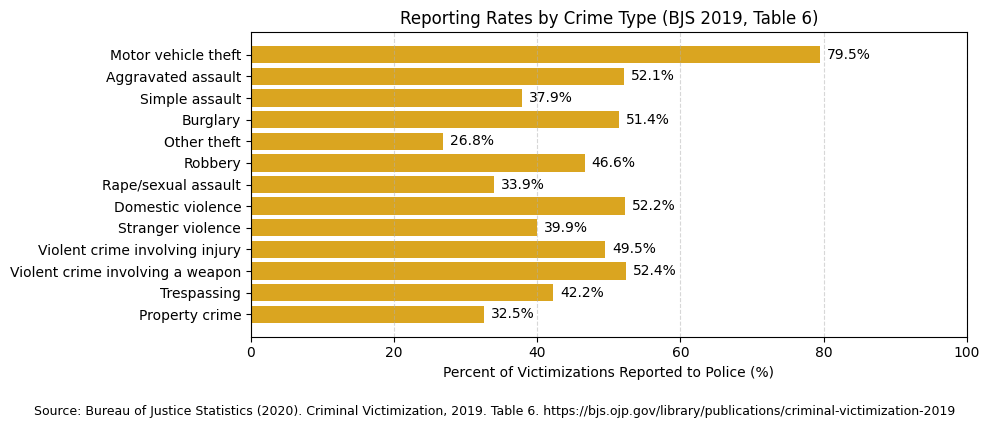

In [35]:
categories = list(bjs_rates.keys())
values = [round(bjs_rates[cat]*100, 1) for cat in categories]

plt.figure(figsize=(10, 4))
bars = plt.barh(categories, values, color='goldenrod')
plt.xlabel('Percent of Victimizations Reported to Police (%)')
plt.title('Reporting Rates by Crime Type (BJS 2019, Table 6)')
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar, val in zip(bars, values):
    plt.text(val + 1, bar.get_y() + bar.get_height() / 2, f'{val}%', va='center')

plt.tight_layout()
plt.figtext(
    0.5, -0.05,
    'Source: Bureau of Justice Statistics (2020). Criminal Victimization, 2019. Table 6. '
    'https://bjs.ojp.gov/library/publications/criminal-victimization-2019',
    wrap=True, ha='center', fontsize=9
)

sns.set_context("notebook", font_scale=1.1)
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

def set_min_figsize(width=10, height=4):
    plt.gcf().set_size_inches(max(width, plt.gcf().get_size_inches()[0]),
                              max(height, plt.gcf().get_size_inches()[1]))

save_title = f'ReportingRates_by_BJS_withCaption'
plt.savefig(f'{save_title}.png')
plt.savefig(f'{save_title}.eps', format='eps')
plt.show()



### Mapping our datasets crime-types to BJS categories

The Baltimore crime dataset includes homicide (n = 1,343) and arson (n = 475) which are not included in BJS report. BJS is based on National Crime Victimization Survey (NCVS). The NCVS gathers data by interviewing people age 12 and older in a household setting about crimes they or their household experienced. This survey does not include fatal crimes because the victim is not available, this explains the exclusion of homicides. The arson however is not included in that survey because it is mostly reported by insurance companies and third parties and that a lot of the times there's no specific victim when the property is a public one.
To handle these two cases:

**Homicide reporting:**
Since the body turns up eventually, homicide is considered a known crime to police. However, by setting the homicides' report rate to 99%, we leave out a one percent chance for the cases that might be miss-categorized as missing person case and the body is never discovered. 

**Arson reporting:**  
National datasets (e.g. ATF’s BATS and USFA/NFIRS) categorize arson by type, property, or intent—but do not estimate how many go unreported. Since it is a form of property crime we use BJS rate for property crime (32.5%) as a conservative proxy.


> Note: These two crime types constitute a marginal share of the dataset—together comprising less than 1.2% of incidents for which BJS-based reporting probabilities are available. Given that our objective is to approximate the general crime reporting probability for simulation purposes, excluding or conservatively estimating categories with limited prevalence and undefined survey-based rates aligns with standard methodological practice.

<!-- These two crime types represent a small proportion of total crimes in our dataset from 2019 onward — together accounting for less than 1.2% of all cases with Known BJS reporting rates. Since our objective is to approximate the general crime reporting probability for simulation purposes, the exclusion or conservative estimation of rare or unquantified categories is consistent with standard practice when grounding simulations in national survey-based metrics.

 -->

In [36]:
Crime_report_probs= {**bjs_rates,'Homicide': 0.99}

In [37]:
crime_map = {
    'AUTO THEFT': 'Motor vehicle theft',
    'AGG. ASSAULT': 'Aggravated assault',
    'COMMON ASSAULT': 'Simple assault',
    'BURGLARY': 'Burglary',
    'TRESPASSING': 'Trespassing',  
    'LARCENY': 'Other theft',
    'LARCENY FROM AUTO': 'Other theft',
    'ROBBERY': 'Robbery',
    'ROBBERY - COMMERCIAL': 'Robbery',
    'ROBBERY - CARJACKING': 'Robbery',
    'RAPE': 'Rape/sexual assault',
    'SHOOTING': 'Violent crime involving a weapon',
    'DOMESTIC VIOLENCE': 'Domestic violence',
    'HOMICIDE': 'Homicide',
    'ARSON': 'Property crime'
}


### Creating weighted reporting probability table

In [38]:
crime_counts = df_Crimes[df_Crimes['year'] >= 2019]['description'].value_counts()
display(crime_counts)

LARCENY                 33536
COMMON ASSAULT          32538
AGG. ASSAULT            21277
LARCENY FROM AUTO       17129
BURGLARY                16618
AUTO THEFT              13185
ROBBERY                 11862
SHOOTING                 2879
ROBBERY - CARJACKING     2183
ROBBERY - COMMERCIAL     1688
HOMICIDE                 1343
RAPE                     1087
ARSON                     475
Name: description, dtype: int64

In [39]:
crime_report_probability_df = crime_counts.rename_axis('Crime').reset_index(name='Crime Count')

crime_report_probability_df['Mapped Category'] = crime_report_probability_df['Crime'].map(crime_map)
crime_report_probability_df['Report Probability'] = crime_report_probability_df['Mapped Category'].map(Crime_report_probs)

crime_report_probability_df['Weighted Contribution'] = (
    crime_report_probability_df['Crime Count'] * crime_report_probability_df['Report Probability']
)

display(crime_report_probability_df)

,Crime,Crime Count,Mapped Category,Report Probability,Weighted Contribution
0,LARCENY,33536,Other theft,0.268,8987.648
1,COMMON ASSAULT,32538,Simple assault,0.379,12331.902
2,AGG. ASSAULT,21277,Aggravated assault,0.521,11085.317
3,LARCENY FROM AUTO,17129,Other theft,0.268,4590.572
4,BURGLARY,16618,Burglary,0.514,8541.652
5,AUTO THEFT,13185,Motor vehicle theft,0.795,10482.075
6,ROBBERY,11862,Robbery,0.466,5527.692
7,SHOOTING,2879,Violent crime involving a weapon,0.524,1508.596
8,ROBBERY - CARJACKING,2183,Robbery,0.466,1017.278
9,ROBBERY - COMMERCIAL,1688,Robbery,0.466,786.608


In [40]:
effective_categories_df = crime_report_probability_df[~crime_report_probability_df['Report Probability'].isna()]
display(effective_categories_df)
weighted_sum = effective_categories_df["Weighted Contribution"].sum()
total_count = effective_categories_df["Crime Count"].sum()

P_reported = weighted_sum.sum() / total_count if total_count > 0 else 0

print(f"Estimated reporting probability: {P_reported:.2%}")


,Crime,Crime Count,Mapped Category,Report Probability,Weighted Contribution
0,LARCENY,33536,Other theft,0.268,8987.648
1,COMMON ASSAULT,32538,Simple assault,0.379,12331.902
2,AGG. ASSAULT,21277,Aggravated assault,0.521,11085.317
3,LARCENY FROM AUTO,17129,Other theft,0.268,4590.572
4,BURGLARY,16618,Burglary,0.514,8541.652
5,AUTO THEFT,13185,Motor vehicle theft,0.795,10482.075
6,ROBBERY,11862,Robbery,0.466,5527.692
7,SHOOTING,2879,Violent crime involving a weapon,0.524,1508.596
8,ROBBERY - CARJACKING,2183,Robbery,0.466,1017.278
9,ROBBERY - COMMERCIAL,1688,Robbery,0.466,786.608


Estimated reporting probability: 42.82%


Rounding the estimated number, we are going to use 0.4 as the report probability of a crime happened after 2018 in Baltimore City. This number is used to do a coin toss with a 0.4 probability of turning heads for each crime in our Baltimore crime dataset to decide which crimes are going to get reported. 

---

## Run

In [41]:
pr=np.linspace(0, 1, 3)#6)# 
pr=np.round(pr,2)
pr

pr= [0.0, 0.4]

In [42]:
sDate = datetime(year=2019, month=1, day=1)
md_periods = {'Monthly':[30], 'Daily':[300]}
CrimeTypes = ['BURGLARY','TOTAL']
pNums = [40,400]
Algs = ['KDE_ShortTerm','KDE_LongTerm','PredPol']
numberOfRuns= 10

cell_run_time = datetime.now().strftime("%Y-%m-%d__%H-%M-%S")

df_resLocs = pd.DataFrame(columns=['prediction_method','Period', 'S_Date','E_Date','crime_type','number_of_police','Algorithm','resLoc' ])

with tqdm(total=len(CrimeTypes)*len(md_periods)*len(Algs)*len(pNums)) as pbarkoll:
    for md, periods in md_periods.items(): 
        for period in periods:

            if md=='Monthly':
                eDate = sDate + relativedelta(months = period)
            else:
                eDate = sDate + relativedelta(days = period)

            for crimeType in CrimeTypes:
                if crimeType == 'BURGLARY':
                    df_crime_to_use = df_Crime_burg
                else:
                    df_crime_to_use = df_Crimes

                for pNum in pNums:
                    for Alg in Algs:
                        print(f"runing {Alg}, period: {period}{md},{crimeType}, policeNumber: {pNum}")
                        if Alg == 'KDE_LongTerm':
                            print("running flat_parallel_simulations_KDE_Long")
                            aNR, resLoc = flat_parallel_simulations_KDE_Long(md = md, df_Crime = df_crime_to_use, 
                                              df_neighood = df_neighood, sDate = sDate, 
                                              eDate = eDate, pr = pr, crimeType = crimeType, 
                                              policeNum=pNum, numberOfRuns=numberOfRuns,cell_run_time=cell_run_time)
                            
                            pbarkoll.update()
                        elif Alg=='PredPol':
                            print("running flat_parallel_simulations_predpol")
    
                            aNR, resLoc= flat_parallel_simulations_predpol(md = md, df_Crime = df_crime_to_use, 
                                              df_neighood = df_neighood, sDate = sDate, 
                                              eDate = eDate, pr = pr, crimeType = crimeType, 
                                              policeNum=pNum, numberOfRuns=numberOfRuns,cell_run_time=cell_run_time)
                            
                            pbarkoll.update()
                        else:
                            print("running flat_parallel_simulations_KDE_short")
                            aNR, resLoc = flat_parallel_simulations_KDE_Short(md = md, df_Crime = df_crime_to_use, 
                                              df_neighood = df_neighood, sDate = sDate, 
                                              eDate = eDate, pr = pr, crimeType = crimeType, 
                                              policeNum=pNum, numberOfRuns=numberOfRuns,cell_run_time=cell_run_time)
                            
                            pbarkoll.update()
                            


                        df_resLocs.loc[len(df_resLocs.index)] = [md, period,sDate,eDate,crimeType,pNum,Alg,resLoc]

df_resLocs.to_csv(f"results/{cell_run_time}/Reslocs.csv", index=False)


  0%|          | 0/24 [00:00<?, ?it/s]

runing KDE_ShortTerm, period: 30Monthly,BURGLARY, policeNumber: 40
runing flat_parallel_simulations_KDE_short
results/2025-08-26__13-28-02/Monthly/BURGLARY/PredYear_2019/Period_912days/PoliceNum_40/KDE_Short_Term/numberOfRuns_10/
Going through 10 rounds of the simulation:


Run 0:   0%|          | 0/2 [00:00<?, ?it/s]

Run 1:   0%|          | 0/2 [00:00<?, ?it/s]

Run 2:   0%|          | 0/2 [00:00<?, ?it/s]

...

Converged at iteration 17
Converged at iteration 19
Converged at iteration 23
Converged at iteration 29
Converged at iteration 35
Converged at iteration 40
Converged at iteration 43
Converged at iteration 46
Converged at iteration 47
Converged at iteration 47
Converged at iteration 48
Converged at iteration 48
Converged at iteration 49
Converged at iteration 49
Converged at iteration 50
Converged at iteration 51
Converged at iteration 51
Converged at iteration 51
Converged at iteration 51
Converged at iteration 52
Converged at iteration 52
Converged at iteration 53
Converged at iteration 53
Converged at iteration 54
Converged at iteration 55
Converged at iteration 55
Converged at iteration 55
Converged at iteration 55
Converged at iteration 56
Converged at iteration 56
Converged at iteration 57
Converged at iteration 57
Converged at iteration 57
Converged at iteration 58
Converged at iteration 58
Converged at iteration 58
Converged at iteration 58
Converged at iteration 58
Converged at

Converged at iteration 17
Converged at iteration 19
Converged at iteration 23
Converged at iteration 29
Converged at iteration 34
Converged at iteration 40
Converged at iteration 43
Converged at iteration 45
Converged at iteration 47
Converged at iteration 47
Converged at iteration 48
Converged at iteration 48
Converged at iteration 49
Converged at iteration 49
Converged at iteration 50
Converged at iteration 51
Converged at iteration 51
Converged at iteration 51
Converged at iteration 51
Converged at iteration 51
Converged at iteration 52
Converged at iteration 52
Converged at iteration 53
Converged at iteration 54
Converged at iteration 55
Converged at iteration 55
Converged at iteration 55
Converged at iteration 56
Converged at iteration 57
Converged at iteration 57
Converged at iteration 57
Converged at iteration 57
Converged at iteration 57
Converged at iteration 58
Converged at iteration 59
Converged at iteration 59
Converged at iteration 58
Converged at iteration 58
Converged at

Converged at iteration 17
Converged at iteration 19
Converged at iteration 23
Converged at iteration 29
Converged at iteration 35
Converged at iteration 39
Converged at iteration 43
Converged at iteration 45
Converged at iteration 47
Converged at iteration 48
Converged at iteration 48
Converged at iteration 49
Converged at iteration 49
Converged at iteration 50
Converged at iteration 51
Converged at iteration 52
Converged at iteration 51
Converged at iteration 52
Converged at iteration 52
Converged at iteration 52
Converged at iteration 52
Converged at iteration 53
Converged at iteration 53
Converged at iteration 55
Converged at iteration 55
Converged at iteration 55
Converged at iteration 56
Converged at iteration 56
Converged at iteration 56
Converged at iteration 56
Converged at iteration 57
Converged at iteration 57
Converged at iteration 57
Converged at iteration 58
Converged at iteration 58
Converged at iteration 59
Converged at iteration 58
Converged at iteration 58
Converged at

Converged at iteration 17
Converged at iteration 19
Converged at iteration 24
Converged at iteration 29
Converged at iteration 34
Converged at iteration 39
Converged at iteration 43
Converged at iteration 45
Converged at iteration 46
Converged at iteration 47
Converged at iteration 47
Converged at iteration 48
Converged at iteration 49
Converged at iteration 49
Converged at iteration 51
Converged at iteration 51
Converged at iteration 51
Converged at iteration 51
Converged at iteration 51
Converged at iteration 51
Converged at iteration 52
Converged at iteration 53
Converged at iteration 53
Converged at iteration 55
Converged at iteration 55
Converged at iteration 55
Converged at iteration 55
Converged at iteration 56
Converged at iteration 56
Converged at iteration 57
Converged at iteration 57
Converged at iteration 57
Converged at iteration 57
Converged at iteration 58
Converged at iteration 58
Converged at iteration 58
Converged at iteration 59
Converged at iteration 58
Converged at

Converged at iteration 17
Converged at iteration 19
Converged at iteration 23
Converged at iteration 29
Converged at iteration 35
Converged at iteration 39
Converged at iteration 43
Converged at iteration 45
Converged at iteration 46
Converged at iteration 47
Converged at iteration 48
Converged at iteration 48
Converged at iteration 49
Converged at iteration 50
Converged at iteration 51
Converged at iteration 51
Converged at iteration 51
Converged at iteration 51
Converged at iteration 51
Converged at iteration 51
Converged at iteration 52
Converged at iteration 52
Converged at iteration 53
Converged at iteration 54
Converged at iteration 54
Converged at iteration 55
Converged at iteration 55
Converged at iteration 55
Converged at iteration 56
Converged at iteration 56
Converged at iteration 57
Converged at iteration 57
Converged at iteration 57
Converged at iteration 58
Converged at iteration 58
Converged at iteration 58
Converged at iteration 58
Converged at iteration 57
Converged at

---

## A Peek at Results Dataframes


In [43]:
display(df_resLocs)


,prediction_method,Period,S_Date,E_Date,crime_type,number_of_police,Algorithm,resLoc
0,Monthly,30,2019-01-01,2021-07-01,BURGLARY,40,KDE_ShortTerm,results/2025-08-26__13-28-02/Monthly/BURGLARY/...
1,Monthly,30,2019-01-01,2021-07-01,BURGLARY,40,KDE_LongTerm,results/2025-08-26__13-28-02/Monthly/BURGLARY/...
2,Monthly,30,2019-01-01,2021-07-01,BURGLARY,40,PredPol,results/2025-08-26__13-28-02/Monthly/BURGLARY/...
3,Monthly,30,2019-01-01,2021-07-01,BURGLARY,400,KDE_ShortTerm,results/2025-08-26__13-28-02/Monthly/BURGLARY/...
4,Monthly,30,2019-01-01,2021-07-01,BURGLARY,400,KDE_LongTerm,results/2025-08-26__13-28-02/Monthly/BURGLARY/...
5,Monthly,30,2019-01-01,2021-07-01,BURGLARY,400,PredPol,results/2025-08-26__13-28-02/Monthly/BURGLARY/...
6,Monthly,30,2019-01-01,2021-07-01,TOTAL,40,KDE_ShortTerm,results/2025-08-26__13-28-02/Monthly/TOTAL/Pre...
7,Monthly,30,2019-01-01,2021-07-01,TOTAL,40,KDE_LongTerm,results/2025-08-26__13-28-02/Monthly/TOTAL/Pre...
8,Monthly,30,2019-01-01,2021-07-01,TOTAL,40,PredPol,results/2025-08-26__13-28-02/Monthly/TOTAL/Pre...
9,Monthly,30,2019-01-01,2021-07-01,TOTAL,400,KDE_ShortTerm,results/2025-08-26__13-28-02/Monthly/TOTAL/Pre...


In [44]:
print(df_resLocs.loc[0,"resLoc"])

results/2025-08-26__13-28-02/Monthly/BURGLARY/PredYear_2019/Period_912days/PoliceNum_40/KDE_Short_Term/numberOfRuns_10/flat_KDE_Short_AverageNeighborResult.csv


In [45]:

sample_avg_nei_res=pd.read_csv(df_resLocs.loc[0,"resLoc"])
display(sample_avg_nei_res[sample_avg_nei_res['DetectedNum']!=0])

,Neighborhood,Date,nextDate,pReport,CrimesNum,PoliceNum,DetectedNum
35,ABELL,2020-06-01,2020-07-01,0.4,1.0,0.7,0.7
37,ABELL,2020-07-01,2020-08-01,0.4,2.0,0.1,0.2
39,ABELL,2020-08-01,2020-09-01,0.4,1.0,0.1,0.1
65,ALLENDALE,2019-03-01,2019-04-01,0.4,8.0,0.6,3.8
67,ALLENDALE,2019-04-01,2019-05-01,0.4,3.0,1.5,2.3
...,...,...,...,...,...,...,...
15245,YALE HEIGHTS,2019-03-01,2019-04-01,0.4,2.0,0.6,1.0
15257,YALE HEIGHTS,2019-09-01,2019-10-01,0.4,7.0,0.2,1.4
15259,YALE HEIGHTS,2019-10-01,2019-11-01,0.4,1.0,0.7,0.5
15261,YALE HEIGHTS,2019-11-01,2019-12-01,0.4,1.0,0.2,0.2


## Concating All Average Neighborhood Result DataFrames in One Master DataFrame

In [46]:
df_resLocs=pd.read_csv(f"results/{cell_run_time}/Reslocs.csv")

In [47]:
from pathlib import Path

setting_cols = df_resLocs.columns.drop('resLoc').tolist()

master_df = pd.concat([
    pd.read_csv(row['resLoc'])
      .assign(**row.drop('resLoc').to_dict())
      .loc[:, setting_cols + [col for col in pd.read_csv(row['resLoc']).columns if col not in setting_cols]]
    for _, row in df_resLocs.iterrows()
    if Path(row['resLoc']).is_file()
], ignore_index=True)

display(master_df)

,prediction_method,Period,S_Date,E_Date,crime_type,number_of_police,Algorithm,Neighborhood,Date,nextDate,pReport,CrimesNum,PoliceNum,DetectedNum
0,Monthly,30,2019-01-01,2021-07-01,BURGLARY,40,KDE_ShortTerm,ABELL,2019-01-01,2019-02-01,0.0,0.0,0.0,0.0
1,Monthly,30,2019-01-01,2021-07-01,BURGLARY,40,KDE_ShortTerm,ABELL,2019-01-01,2019-02-01,0.4,0.0,0.0,0.0
2,Monthly,30,2019-01-01,2021-07-01,BURGLARY,40,KDE_ShortTerm,ABELL,2019-02-01,2019-03-01,0.0,1.0,0.0,0.0
3,Monthly,30,2019-01-01,2021-07-01,BURGLARY,40,KDE_ShortTerm,ABELL,2019-02-01,2019-03-01,0.4,1.0,0.0,0.0
4,Monthly,30,2019-01-01,2021-07-01,BURGLARY,40,KDE_ShortTerm,ABELL,2019-03-01,2019-04-01,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2027515,Daily,300,2019-01-01,2019-10-28,TOTAL,400,PredPol,YORK-HOMELAND,2019-10-25,2019-10-26,0.4,0.0,0.0,0.0
2027516,Daily,300,2019-01-01,2019-10-28,TOTAL,400,PredPol,YORK-HOMELAND,2019-10-26,2019-10-27,0.0,0.0,0.1,0.0
2027517,Daily,300,2019-01-01,2019-10-28,TOTAL,400,PredPol,YORK-HOMELAND,2019-10-26,2019-10-27,0.4,0.0,0.0,0.0
2027518,Daily,300,2019-01-01,2019-10-28,TOTAL,400,PredPol,YORK-HOMELAND,2019-10-27,2019-10-28,0.0,0.0,0.0,0.0


In [48]:
print(f"results/{cell_run_time}/master_df.csv")

results/2025-08-26__13-28-02/master_df.csv


In [49]:
master_df.to_csv(f"results/{cell_run_time}/master_df.csv", index=False)


In [50]:
master_df3 = pd.read_csv(f"results/{cell_run_time}/master_df.csv")
display(master_df3)

,prediction_method,Period,S_Date,E_Date,crime_type,number_of_police,Algorithm,Neighborhood,Date,nextDate,pReport,CrimesNum,PoliceNum,DetectedNum
0,Monthly,30,2019-01-01,2021-07-01,BURGLARY,40,KDE_ShortTerm,ABELL,2019-01-01,2019-02-01,0.0,0.0,0.0,0.0
1,Monthly,30,2019-01-01,2021-07-01,BURGLARY,40,KDE_ShortTerm,ABELL,2019-01-01,2019-02-01,0.4,0.0,0.0,0.0
2,Monthly,30,2019-01-01,2021-07-01,BURGLARY,40,KDE_ShortTerm,ABELL,2019-02-01,2019-03-01,0.0,1.0,0.0,0.0
3,Monthly,30,2019-01-01,2021-07-01,BURGLARY,40,KDE_ShortTerm,ABELL,2019-02-01,2019-03-01,0.4,1.0,0.0,0.0
4,Monthly,30,2019-01-01,2021-07-01,BURGLARY,40,KDE_ShortTerm,ABELL,2019-03-01,2019-04-01,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2027515,Daily,300,2019-01-01,2019-10-28,TOTAL,400,PredPol,YORK-HOMELAND,2019-10-25,2019-10-26,0.4,0.0,0.0,0.0
2027516,Daily,300,2019-01-01,2019-10-28,TOTAL,400,PredPol,YORK-HOMELAND,2019-10-26,2019-10-27,0.0,0.0,0.1,0.0
2027517,Daily,300,2019-01-01,2019-10-28,TOTAL,400,PredPol,YORK-HOMELAND,2019-10-26,2019-10-27,0.4,0.0,0.0,0.0
2027518,Daily,300,2019-01-01,2019-10-28,TOTAL,400,PredPol,YORK-HOMELAND,2019-10-27,2019-10-28,0.0,0.0,0.0,0.0


### References

1. <a name="ref1"></a>Morgan, R. E., & Truman, J. L. (2020). *Criminal Victimization, 2019*. Bureau of Justice Statistics, U.S. Department of Justice.  
   https://bjs.ojp.gov/content/pub/pdf/cv19.pdf
